# Problem Statement

## Business Problem

Many people in East Africa still lack access to formal financial services, including commercial bank accounts. This can make it harder for individuals and households to save securely, receive payments, access credit, purchase insurance, and build long-term financial stability.

Banks, FinTech companies, governments, and development organisations need to understand which population groups are least likely to have a bank account. This information can help them design more targeted financial-inclusion initiatives, such as mobile banking services, financial-literacy programmes, accessible account products, or regional outreach campaigns.

## Machine Learning Problem

Using survey data from Kenya, Rwanda, Tanzania, and Uganda, we will build a binary classification model that predicts whether an individual is likely to have or use a bank account.

The target variable is `bank_account`:

- `Yes`: The individual has or uses a bank account.
- `No`: The individual does not have or use a bank account.

The model will use characteristics such as country, location type, mobile-phone access, age, gender, education level, household size, marital status, and employment type.

## Project Goal

The goal is to identify the key factors associated with bank-account ownership and build a reliable model that supports better targeting of financial-inclusion efforts across East Africa.

---

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data_path = (
    "/Users/nabilelfadel/Desktop/"
    "financial-inclusion-in-africa20250311-22142-nbnoiv/"
)

train = pd.read_csv(data_path + "Train.csv")
test = pd.read_csv(data_path + "Test.csv")
variables = pd.read_csv(data_path + "VariableDefinitions.csv")

In [6]:
variables

,Variable Definitions,Unnamed: 1
0,country,Country interviewee is in.
1,year,Year survey was done in.
2,uniqueid,Unique identifier for each interviewee
3,location_type,"Type of location: Rural, Urban"
4,cellphone_access,"If interviewee has access to a cellphone: Yes, No"
5,household_size,Number of people living in one house
6,age_of_respondent,The age of the interviewee
7,gender_of_respondent,"Gender of interviewee: Male, Female"
8,relationship_with_head,The interviewee’s relationship with the head o...
9,marital_status,The martial status of the interviewee: Married...


In [7]:
train.shape

(23524, 13)

In [8]:
train.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [9]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   country                 23524 non-null  str  
 1   year                    23524 non-null  int64
 2   uniqueid                23524 non-null  str  
 3   bank_account            23524 non-null  str  
 4   location_type           23524 non-null  str  
 5   cellphone_access        23524 non-null  str  
 6   household_size          23524 non-null  int64
 7   age_of_respondent       23524 non-null  int64
 8   gender_of_respondent    23524 non-null  str  
 9   relationship_with_head  23524 non-null  str  
 10  marital_status          23524 non-null  str  
 11  education_level         23524 non-null  str  
 12  job_type                23524 non-null  str  
dtypes: int64(3), str(10)
memory usage: 2.3 MB


<span style="color:green"> Columns 13 / Rows: 23.524
10 String Columns
3 Int Columns
We can also see that there are no missing values, all columns have the same total row numbers!

In [10]:
# Dataset size: rows and columns
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (23524, 13)
Test shape: (10086, 12)


In [11]:
# Summary statistics for categorical columns
train.describe(include="object")

/var/folders/xd/z5xpb5h532dfrdy6xz3v34t40000gn/T/ipykernel_83522/108521615.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train.describe(include="object")


,country,uniqueid,bank_account,location_type,cellphone_access,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
count,23524,23524,23524,23524,23524,23524,23524,23524,23524,23524
unique,4,8735,2,2,2,2,6,5,6,10
top,Rwanda,uniqueid_1,No,Rural,Yes,Female,Head of Household,Married/Living together,Primary education,Self employed
freq,8735,4,20212,14343,17454,13877,12831,10749,12791,6437


In [12]:
# Check missing values
missing_values = train.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

In [13]:
# Check for missing values
print('missing values:', train.isnull().sum())

missing values: country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64


In [14]:
# Check duplicate rows
print("Duplicate rows:", train.duplicated().sum())

# uniqueid should identify each respondent uniquely
print("Duplicate IDs:", train["uniqueid"].duplicated().sum())

Duplicate rows: 0
Duplicate IDs: 14789


We don't have missing data in our dataset or duplicat rows, which is a good sign for now.

In [15]:
# Target distribution: absolute values and percentages
target_counts = train["bank_account"].value_counts()
target_percentages = train["bank_account"].value_counts(
    normalize=True
).mul(100).round(2)

print(target_counts)
print(target_percentages)

bank_account
No     20212
Yes     3312
Name: count, dtype: int64
bank_account
No     85.92
Yes    14.08
Name: proportion, dtype: float64


85% don't have a bank account!!!

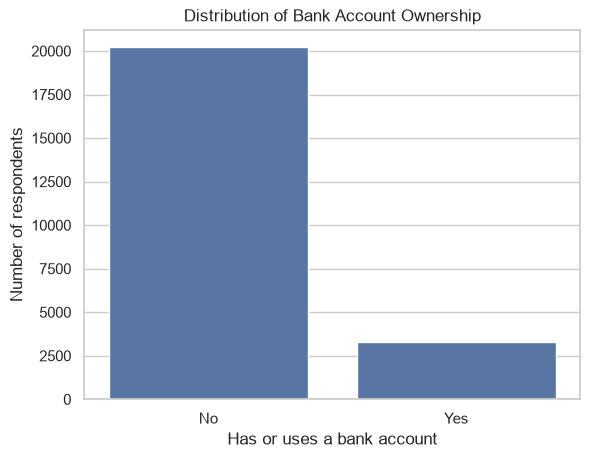

In [16]:
# Visualise the target imbalance
sns.countplot(data=train, x="bank_account", order=["No", "Yes"])
plt.title("Distribution of Bank Account Ownership")
plt.xlabel("Has or uses a bank account")
plt.ylabel("Number of respondents")
plt.show()

In [17]:
# Display distinct values per column
for column in train.columns:
    print(f"\n{column}: {train[column].nunique()} unique values")
    print(train[column].unique()[:15])


country: 4 unique values
<StringArray>
['Kenya', 'Rwanda', 'Tanzania', 'Uganda']
Length: 4, dtype: str

year: 3 unique values
[2018 2016 2017]

uniqueid: 8735 unique values
<StringArray>
[ 'uniqueid_1',  'uniqueid_2',  'uniqueid_3',  'uniqueid_4',  'uniqueid_5',
  'uniqueid_6',  'uniqueid_7',  'uniqueid_8',  'uniqueid_9', 'uniqueid_10',
 'uniqueid_11', 'uniqueid_12', 'uniqueid_13', 'uniqueid_14', 'uniqueid_15']
Length: 15, dtype: str

bank_account: 2 unique values
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

location_type: 2 unique values
<StringArray>
['Rural', 'Urban']
Length: 2, dtype: str

cellphone_access: 2 unique values
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

household_size: 20 unique values
[ 3  5  8  7  1  6  4 10  2 11  9 12 16 15 13]

age_of_respondent: 85 unique values
[24 70 26 34 32 42 54 76 40 69 64 31 38 47 27]

gender_of_respondent: 2 unique values
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

relationship_with_head: 6 unique values
<StringA

For categorical attributes its important how the proportion will be divided between the different groups. 

In [18]:
categorical_columns = [
    "country",
    "year",
    "location_type",
    "cellphone_access",
    "gender_of_respondent",
    "relationship_with_head",
    "marital_status",
    "education_level",
    "job_type",
]

for column in categorical_columns:
    account_rate = (
        pd.crosstab(
            train[column],
            train["bank_account"],
            normalize="index"
        )
        .mul(100)
        .round(1)
    )
    
    print(f"\nBank-account rate by {column}:")
    print(account_rate)


Bank-account rate by country:
bank_account    No   Yes
country                 
Kenya         74.9  25.1
Rwanda        88.5  11.5
Tanzania      90.8   9.2
Uganda        91.4   8.6

Bank-account rate by year:
bank_account    No   Yes
year                    
2016          88.5  11.5
2017          90.8   9.2
2018          79.2  20.8

Bank-account rate by location_type:
bank_account     No   Yes
location_type            
Rural          88.3  11.7
Urban          82.1  17.9

Bank-account rate by cellphone_access:
bank_account        No   Yes
cellphone_access            
No                98.3   1.7
Yes               81.6  18.4

Bank-account rate by gender_of_respondent:
bank_account            No   Yes
gender_of_respondent            
Female                89.3  10.7
Male                  81.0  19.0

Bank-account rate by relationship_with_head:
bank_account              No   Yes
relationship_with_head            
Child                   91.3   8.7
Head of Household       82.3  17.7
Other n

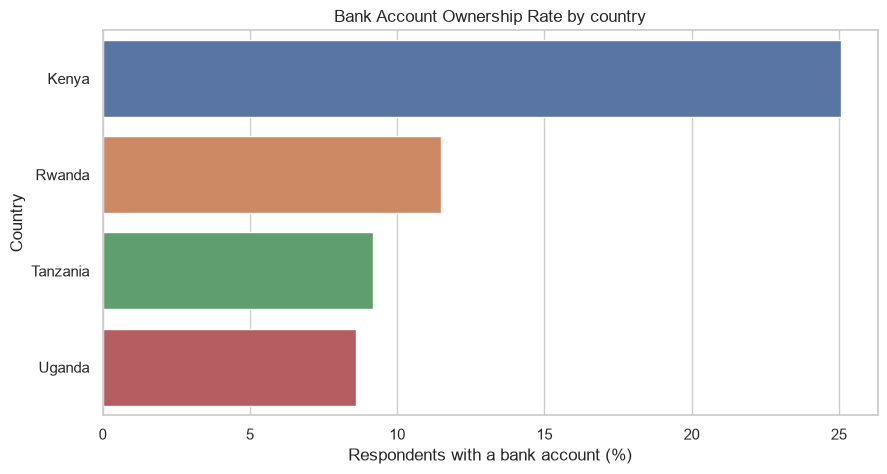

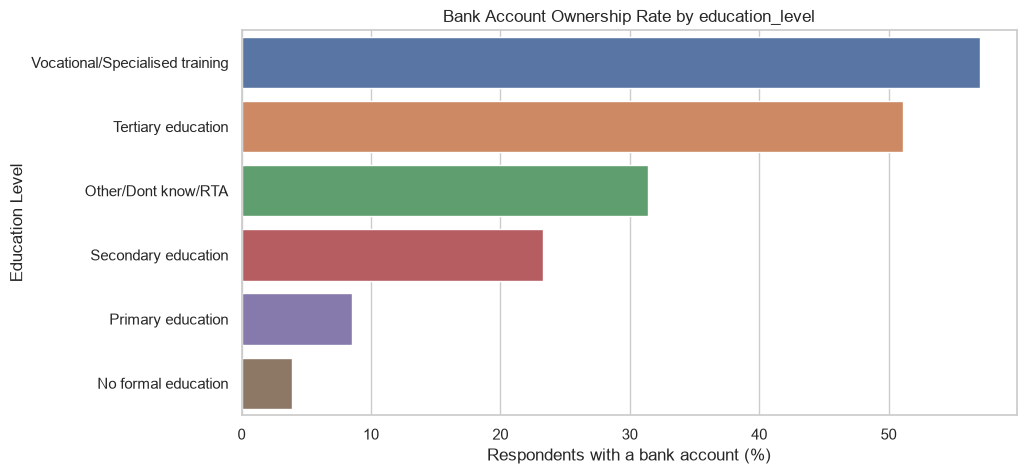

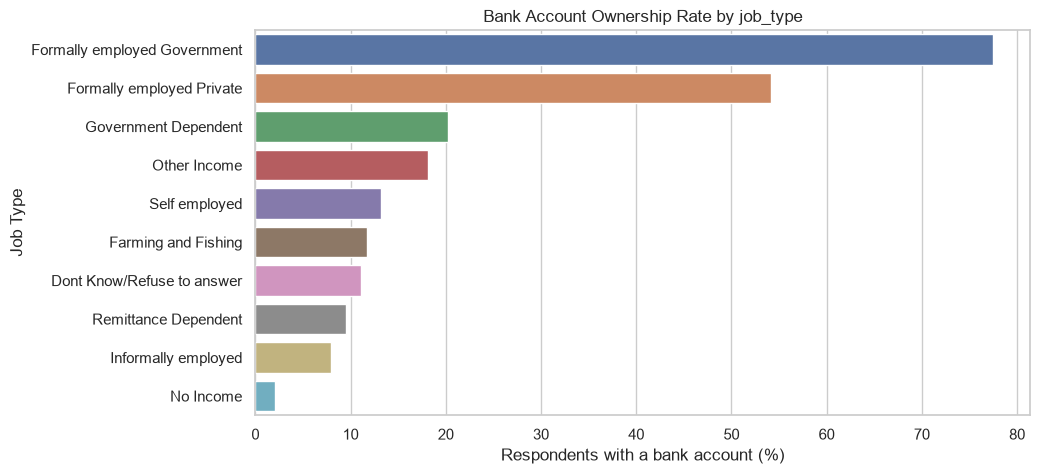

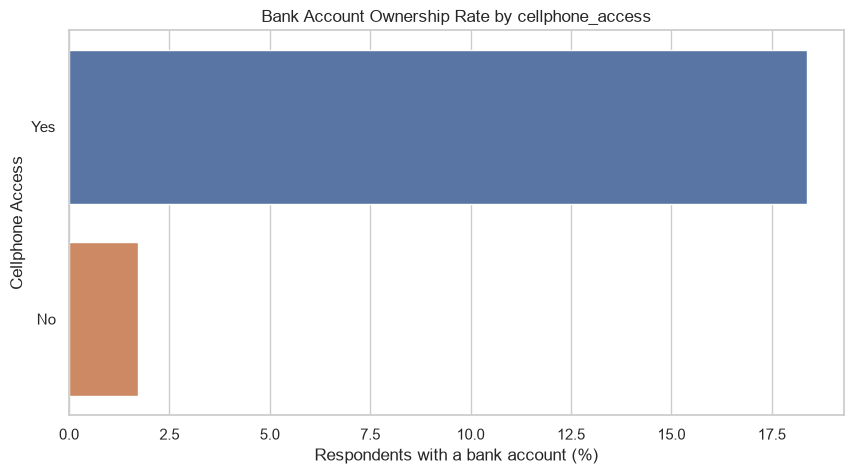

In [19]:
def plot_account_rate_by_group(data, column):
    rates = (
        data.assign(has_account=data["bank_account"].eq("Yes"))
        .groupby(column)["has_account"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(x=rates.values, y=rates.index, hue=rates.index, legend=False)
    plt.title(f"Bank Account Ownership Rate by {column}")
    plt.xlabel("Respondents with a bank account (%)")
    plt.ylabel(column.replace("_", " ").title())
    plt.show()


plot_account_rate_by_group(train, "country")
plot_account_rate_by_group(train, "education_level")
plot_account_rate_by_group(train, "job_type")
plot_account_rate_by_group(train, "cellphone_access")

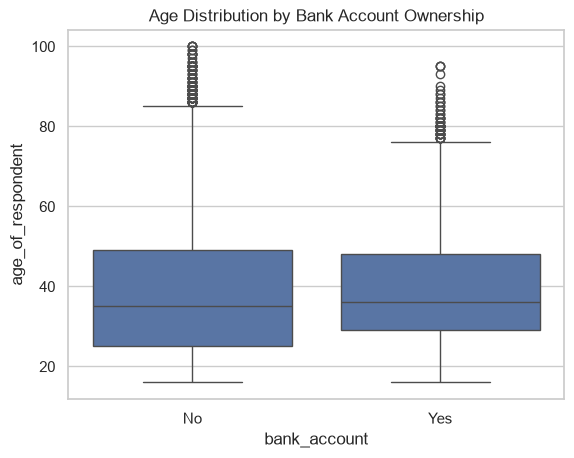

In [20]:
sns.boxplot(
    data=train,
    x="bank_account",
    y="age_of_respondent",
    order=["No", "Yes"]
)
plt.title("Age Distribution by Bank Account Ownership")
plt.show()

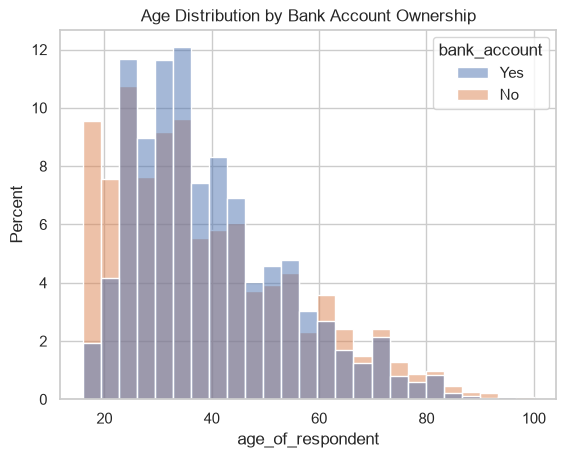

In [21]:
sns.histplot(
    data=train,
    x="age_of_respondent",
    hue="bank_account",
    bins=25,
    multiple="layer",
    stat="percent",
    common_norm=False
)
plt.title("Age Distribution by Bank Account Ownership")
plt.show()

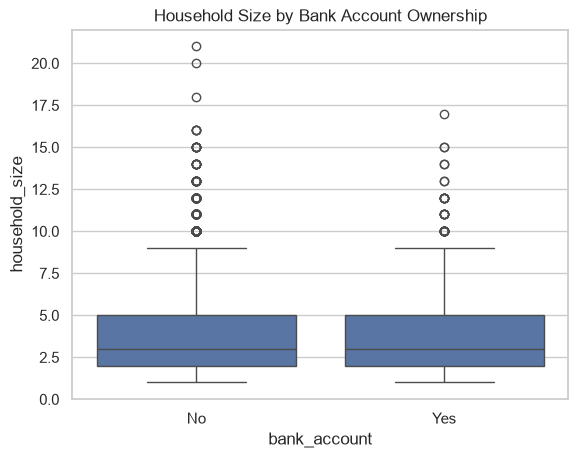

In [22]:
sns.boxplot(
    data=train,
    x="bank_account",
    y="household_size",
    order=["No", "Yes"]
)
plt.title("Household Size by Bank Account Ownership")
plt.show()

In [23]:
feature_columns = test.columns.drop("uniqueid")

for column in feature_columns:
    train_values = set(train[column].dropna().unique())
    test_values = set(test[column].dropna().unique())

    unseen_in_test = test_values - train_values

    if unseen_in_test:
        print(
            f"{column}: Values in test but not in train: "
            f"{unseen_in_test}"
        )

No unseen categorical values were found in the test dataset. Therefore, all categories in the test data are already represented in the training data, which reduces the risk of encoding errors during model preparation.

----


## Project Progress

So far, we have defined the business and machine learning problem. Our goal is to predict whether a person in Kenya, Rwanda, Tanzania, or Uganda is likely to have or use a bank account. This can help banks, FinTech companies, governments, and development organisations better understand financial inclusion and target support to groups that need it most.
We have also explored the dataset using Train.csv, which contains 23,524 survey responses and the target variable bank_account. The target variable has two classes:

- Yes: The respondent has or uses a bank account.
- No: The respondent does not have or use a bank account.

During the exploratory data analysis, we checked the dataset structure, column data types, missing values, duplicate rows, numerical summaries, and the unique categories within the variables. We also examined the distribution of the target variable and found that the data is imbalanced: approximately 14% of respondents have a bank account, while approximately 86% do not.
We investigated how bank-account ownership differs across important variables such as country, location type, mobile-phone access, gender, education level, employment type, age, and household size. Finally, we compared the categories in the training and test datasets. No new categories were found in the test dataset, which means that the test data is compatible with the training data for later preprocessing and encoding.


## Current Project Stage
We are currently in the Exploratory Data Analysis (EDA) stage. We understand the structure and main patterns of the data, and we have identified class imbalance as an important issue for the modelling phase.

----

## Next Steps

1. Prepare the data for machine learning by separating the features from the target variable and removing `uniqueid`, since it is only an identifier.

2. Split the training data into training and validation sets using stratified sampling to preserve the class distribution.

3. Build a simple baseline model, for example:
   - Dummy Classifier
   - Logistic Regression

4. Preprocess the data using a pipeline:
   - One-hot encode categorical variables.
   - Scale numerical variables where needed.
   - Apply the same preprocessing consistently to training, validation, and test data.

5. Train and compare at least three machine learning models, such as:
   - Logistic Regression
   - Random Forest
   - Gradient Boosting or XGBoost

6. Use cross-validation and hyperparameter tuning to improve the best-performing model.

7. Evaluate the models using:
   - Accuracy
   - Error Rate
   - Precision
   - Recall
   - F1 Score
   - Confusion Matrix

   > Because the target variable is imbalanced, special attention should be paid to performance on respondents who have a bank account.

8. Perform error analysis to understand which groups are most frequently predicted incorrectly.

9. Interpret the most important features and translate the findings into practical recommendations for stakeholders.

10. Create the final deliverables:
    - A well-documented Jupyter Notebook
    - A prediction file for the test dataset
    - A stakeholder presentation
    - A slide describing a potential data product based on the model

---

## Feature and Target Preparation

The next step in the machine learning process is to prepare the dataset for model development. At this stage, `Train.csv` is used to separate the available information into model features (`X`) and the target variable (`y`). The identifier `uniqueid` is excluded, as it only serves to uniquely identify individuals and does not provide meaningful predictive information.

The following cells should be executed in the specified order to prepare the data for the subsequent steps of the machine learning workflow.


---

1. Sicherheitskopie des Trainingsdatensatzes erstellen
So veränderst du nicht versehentlich dein ursprüngliches train-DataFrame:

In [24]:
model_data = train.copy()

# model_data ist nun die Arbeitsversion für das Machine Learning.

In [25]:
required_columns = ["bank_account", "uniqueid"]

for column in required_columns:
    if column in model_data.columns:
        print(f"✓ {column} is available.")
    else:
        print(f"✗ {column} is missing.")

✓ bank_account is available.
✓ uniqueid is available.


Die Zielvariable (y) erstellen
y enthält nur die Werte, die vorhergesagt werden sollen:

In [26]:
y = model_data["bank_account"]

In [27]:
print(y.value_counts())
print(y.value_counts(normalize=True).mul(100).round(2))

bank_account
No     20212
Yes     3312
Name: count, dtype: int64
bank_account
No     85.92
Yes    14.08
Name: proportion, dtype: float64


Dabei ist zu erkennen, dass No deutlich häufiger vorkommt als Yes. Das bestätigt die Klassenimbalance.

Zielvariable in 0 und 1 umwandeln
Für die meisten Modelle ist eine numerische Zielvariable übersichtlicher:

In [28]:
target_mapping = {
    "No": 0,
    "Yes": 1
}

y = y.map(target_mapping)

In [29]:
print(y.value_counts())
print(y.head())

bank_account
0    20212
1     3312
Name: count, dtype: int64
0    1
1    0
2    1
3    0
4    0
Name: bank_account, dtype: int64


In [30]:
X = model_data.drop(columns=["bank_account", "uniqueid"])

In [31]:
print("Feature columns:")
print(X.columns.tolist())

print("\nFeature dataset shape:")
print(X.shape)

print("\nFirst five feature rows:")
display(X.head())

Feature columns:
['country', 'year', 'location_type', 'cellphone_access', 'household_size', 'age_of_respondent', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']

Feature dataset shape:
(23524, 11)

First five feature rows:


,country,year,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


Prüfen, ob Features und Zielvariable dieselbe Anzahl an Zeilen haben

In [32]:
print("Number of rows in X:", X.shape[0])
print("Number of rows in y:", y.shape[0])

assert X.shape[0] == y.shape[0], (
    "X and y must contain the same number of rows."
)

print("✓ X and y have matching row counts.")

Number of rows in X: 23524
Number of rows in y: 23524
✓ X and y have matching row counts.


In [33]:
X_test = test.drop(columns=["uniqueid"])

In [34]:
print("Training feature columns:")
print(X.columns.tolist())

print("\nTest feature columns:")
print(X_test.columns.tolist())

assert list(X.columns) == list(X_test.columns), (
    "Training and test features must have the same columns "
    "in the same order."
)

print("\n✓ Training and test data have matching feature columns.")

Training feature columns:
['country', 'year', 'location_type', 'cellphone_access', 'household_size', 'age_of_respondent', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']

Test feature columns:
['country', 'year', 'location_type', 'cellphone_access', 'household_size', 'age_of_respondent', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']

✓ Training and test data have matching feature columns.


In [35]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (23524, 11)
y shape: (23524,)
X_test shape: (10086, 11)


In [36]:
# Importieren der Funktion

from sklearn.model_selection import train_test_split

In [37]:
# Ausgangsdaten kontrollieren 

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution before splitting:")
print(y.value_counts())

print("\nTarget distribution before splitting (%):")
print(y.value_counts(normalize=True).mul(100).round(2))

X shape: (23524, 11)
y shape: (23524,)

Target distribution before splitting:
bank_account
0    20212
1     3312
Name: count, dtype: int64

Target distribution before splitting (%):
bank_account
0    85.92
1    14.08
Name: proportion, dtype: float64


In [38]:
#Trainings- und Validierungsdaten erstellen

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [39]:
# Größen der vier neuen Datensätze prüfen

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (18819, 11)
X_valid shape: (4705, 11)
y_train shape: (18819,)
y_valid shape: (4705,)


In [40]:
print("Total rows after splitting:", len(X_train) + len(X_valid))
print("Original number of rows:", len(X))

Total rows after splitting: 23524
Original number of rows: 23524


In [41]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nValidation target distribution:")
print(y_valid.value_counts())

Training target distribution:
bank_account
0    16169
1     2650
Name: count, dtype: int64

Validation target distribution:
bank_account
0    4043
1     662
Name: count, dtype: int64


In [42]:
class_distribution = pd.DataFrame({
    "Full training data": y.value_counts(normalize=True),
    "Training split": y_train.value_counts(normalize=True),
    "Validation split": y_valid.value_counts(normalize=True)
}).mul(100).round(2)

class_distribution.index = [
    "No bank account (0)",
    "Has bank account (1)"
]

class_distribution

,Full training data,Training split,Validation split
No bank account (0),85.92,85.92,85.93
Has bank account (1),14.08,14.08,14.07


In [43]:
overlapping_indices = X_train.index.intersection(X_valid.index)

print(
    "Number of rows occurring in both datasets:",
    len(overlapping_indices)
)

Number of rows occurring in both datasets: 0


In [44]:
assert list(X_train.columns) == list(X_valid.columns), (
    "Training and validation data must contain "
    "the same feature columns."
)

print("Training and validation data have identical features.")

Training and validation data have identical features.


## Train-Validation Split

The original training dataset was divided into a training set (80%) and a validation set (20%). We used stratified sampling based on the target variable `bank_account` to preserve the original class distribution in both subsets.

This is particularly important because the target variable is imbalanced: approximately 86% of respondents do not have a bank account, while only approximately 14% do. Stratification ensures that the model is trained and evaluated on representative data.

The validation set will be used to compare models and evaluate their performance before the final model is trained on the complete training dataset.

---
## Data-Preprocessing

Als nächstes führen wir die Datenvorbereitung (Preprocessing) durch. Das ist nötig, weil ML-Modelle nicht direkt mit Textwerten wie Kenya, Female oder Self employed arbeiten können.
Wir erstellen eine sichere Pipeline, die:

- numerische Werte behandelt,
- kategoriale Werte in Zahlen umwandelt,
- fehlende Werte abfangen kann,
- Data Leakage vermeidet,
- später exakt gleich auf Validierungs- und Testdaten angewendet wird.

1. Feature-Typen festlegen
Führe diese Zelle aus:

In [45]:
numerical_features = [
    "year",
    "household_size",
    "age_of_respondent"
]

categorical_features = [
    "country",
    "location_type",
    "cellphone_access",
    "gender_of_respondent",
    "relationship_with_head",
    "marital_status",
    "education_level",
    "job_type"
]

In [46]:
all_features = numerical_features + categorical_features

print("Number of defined features:", len(all_features))
print("Number of columns in X_train:", X_train.shape[1])

assert set(all_features) == set(X_train.columns), (
    "The defined feature lists do not match X_train columns."
)

print("All features were assigned to a feature type.")

Number of defined features: 11
Number of columns in X_train: 11
All features were assigned to a feature type.


In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

Bedeutung:

- SimpleImputer: Ersetzt gegebenenfalls fehlende Werte.
- StandardScaler: Bringt numerische Werte auf eine vergleichbare Skala.
- OneHotEncoder: Wandelt Textkategorien in 0/1-Spalten um.
- ColumnTransformer: Wendet unterschiedliche Schritte auf verschiedene Spaltengruppen an.
- Pipeline: Verbindet alle Schritte sicher zu einem wiederverwendbaren Ablauf.

In [48]:
# Pipeline for numerical features.

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

Was passiert hier?

1. Falls bei Alter, Haushaltsgröße oder Jahr ein Wert fehlen würde, ersetzt SimpleImputer ihn durch den Median.
2. StandardScaler standardisiert die Werte. Zum Beispiel liegen Alter und Haushaltsgröße danach auf einer vergleichbaren Skala.

Der Scaler wird ausschließlich mit X_train gelernt. Der Mittelwert und die Standardabweichung der Validierungsdaten werden nicht verwendet.

In [49]:
# Pipeline for categorical features.

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "one_hot_encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

Was passiert hier?

Fehlende Textwerte würden durch die häufigste Kategorie ersetzt.
OneHotEncoder erstellt aus jeder Kategorie eigene 0/1-Spalten.

handle_unknown="ignore" ist eine wichtige Sicherheitsvorkehrung: Falls später eine neue Kategorie auftaucht, bricht der Code nicht ab. Stattdessen werden die entsprechenden One-Hot-Spalten mit 0 gesetzt.

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_transformer, numerical_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

6. Preprocessor nur mit Trainingsdaten fitten. Das ist einer der wichtigsten Schritte:

In [51]:
X_train_prepared = preprocessor.fit_transform(X_train)

fit_transform() bedeutet:

- fit: Der Preprocessor lernt nur aus X_train, zum Beispiel Kategorien, Medianwerte und Skalierungswerte.
- transform: Anschließend werden die Trainingsdaten in ein Format für ML-Modelle umgewandelt.

In [52]:
# Validation data should be transformed using the same preprocessor fitted on the training data.

X_valid_prepared = preprocessor.transform(X_valid)

Hier wird bewusst nur transform() verwendet — nicht fit_transform().

Dadurch verwendet die Validierung exakt dieselben Regeln wie das Training. Das verhindert Data Leakage und simuliert neue, unbekannte Daten.

In [53]:
print("Original training shape:", X_train.shape)
print("Prepared training shape:", X_train_prepared.shape)

print("\nOriginal validation shape:", X_valid.shape)
print("Prepared validation shape:", X_valid_prepared.shape)

Original training shape: (18819, 11)
Prepared training shape: (18819, 40)

Original validation shape: (4705, 11)
Prepared validation shape: (4705, 40)


Die Anzahl der Spalten wird nach One-Hot-Encoding deutlich größer sein. Das ist korrekt: Eine Textspalte wie job_type wird zu mehreren binären Spalten.

In [54]:
assert X_train_prepared.shape[1] == X_valid_prepared.shape[1], (
    "Prepared training and validation data must "
    "have the same number of features."
)

print("Training and validation data have matching prepared features.")

Training and validation data have matching prepared features.


In [55]:
prepared_feature_names = preprocessor.get_feature_names_out()

print("Number of prepared features:", len(prepared_feature_names))
print("\nFirst 20 prepared feature names:")
print(prepared_feature_names[:20])

Number of prepared features: 40

First 20 prepared feature names:
['numerical__year' 'numerical__household_size'
 'numerical__age_of_respondent' 'categorical__country_Kenya'
 'categorical__country_Rwanda' 'categorical__country_Tanzania'
 'categorical__country_Uganda' 'categorical__location_type_Rural'
 'categorical__location_type_Urban' 'categorical__cellphone_access_No'
 'categorical__cellphone_access_Yes'
 'categorical__gender_of_respondent_Female'
 'categorical__gender_of_respondent_Male'
 'categorical__relationship_with_head_Child'
 'categorical__relationship_with_head_Head of Household'
 'categorical__relationship_with_head_Other non-relatives'
 'categorical__relationship_with_head_Other relative'
 'categorical__relationship_with_head_Parent'
 'categorical__relationship_with_head_Spouse'
 'categorical__marital_status_Divorced/Seperated']


Testdaten noch nicht fitten, nur transformieren

Preprocessor schon mit dem Training gelernt. Für das externe Testset gilt deshalb ebenfalls nur transform():

In [56]:
X_test_prepared = preprocessor.transform(X_test)

print("Prepared test shape:", X_test_prepared.shape)

Prepared test shape: (10086, 40)


In [57]:
assert X_train_prepared.shape[1] == X_test_prepared.shape[1], (
    "Prepared training and test data must "
    "have the same number of features."
)

print("Test data is ready for final predictions later.")

Test data is ready for final predictions later.


## Data Preprocessing

The dataset contains numerical and categorical variables. Numerical variables (`year`, `household_size`, and `age_of_respondent`) were imputed using the median and standardised using `StandardScaler`.

Categorical variables were imputed with their most frequent value and transformed using one-hot encoding. The preprocessing steps were fitted only on the training subset and then applied unchanged to the validation and test subsets. This prevents data leakage and ensures that model evaluation reflects performance on unseen data.

The variable `uniqueid` was excluded because it is an identifier and does not provide meaningful predictive information.

---

## Baseline

Jetzt erstellen und bewerten wir die ersten zwei Modelle:

1. Dummy Baseline: sagt immer die Mehrheitsklasse voraus.
2. Logistic Regression: erstes echtes ML-Modell.

Dieser Schritt ist wichtig, weil ein Modell nur dann nützlich ist, wenn es besser als eine sehr einfache Regel ist.

Warum brauchen wir eine Baseline?

In unserem Dataset haben ungefähr 86 % der Personen kein Bankkonto.
Ein extrem einfaches Modell könnte daher immer sagen:

Dieses Modell hätte ungefähr 86 % Accuracy, obwohl es keine einzige Person mit Bankkonto erkennt. Das zeigt, warum Accuracy bei unausgeglichenen Daten allein nicht ausreicht.
Die Baseline gibt uns einen Mindeststandard:
Unser echtes ML-Modell sollte mindestens bessere und sinnvollere Ergebnisse liefern als die Regel „alle haben kein Bankkonto“.

In [58]:
# Benötigte Bibliotheken importieren

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)

Für dieses Projekt ist accuracy die ursprüngliche Competition-Metrik. Wegen der Klassenimbalance betrachten wir aber zusätzlich Precision, Recall und F1 Score für die positive Klasse 1.

### Hilfsfunktion zur Modellbewertung erstellen

Diese Funktion berechnet für jedes Modell dieselben Kennzahlen. Dadurch können die  Modelle später sauber vergleiche werden.

In [59]:
def evaluate_model(model_name, y_true, y_pred):
    """
    Prints classification metrics for a binary classifier.

    Parameters
    ----------
    model_name : str
        Name displayed in the evaluation output.
    y_true : pandas Series or array-like
        Actual target values.
    y_pred : numpy array or array-like
        Predicted target values.
    """
    accuracy = accuracy_score(y_true, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"Model: {model_name}")
    print("-" * 40)
    print(f"Accuracy:          {accuracy:.3f}")
    print(f"Balanced accuracy: {balanced_accuracy:.3f}")
    print(f"Precision:         {precision:.3f}")
    print(f"Recall:            {recall:.3f}")
    print(f"F1 score:          {f1:.3f}")

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=["No bank account", "Has bank account"],
            zero_division=0
        )
    )

In [60]:
# Dummy BAseline trainieren

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

strategy="most_frequent" bedeutet:

- Das Modell schaut auf y_train.
- Es erkennt, dass 0 (No bank account) die häufigste Klasse ist.
- Es sagt bei jeder Person 0 vorher.

In [61]:
dummy_model.fit(X_train_prepared, y_train)

# Dadurch lert der DummyClassifier, welche Zielklasse im Trainingsset am häufigsten vorkommen.

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.86,0.14]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,40
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [62]:
# Vorhersagen mit der Bseline erzeugen

dummy_predictions = dummy_model.predict(X_valid_prepared)

In [63]:
print("Predicted classes:")
print(pd.Series(dummy_predictions).value_counts())

print("\nActual classes:")
print(y_valid.value_counts())

Predicted classes:
0    4705
Name: count, dtype: int64

Actual classes:
bank_account
0    4043
1     662
Name: count, dtype: int64


Das Dummy-Modell sagt für alle 4705 Personen, kein Bankkonto!

In [64]:
# Dummy BAseline bewerten

evaluate_model(
    model_name="Dummy Classifier (Most Frequent)",
    y_true=y_valid,
    y_pred=dummy_predictions
)


Model: Dummy Classifier (Most Frequent)
----------------------------------------
Accuracy:          0.859
Balanced accuracy: 0.500
Precision:         0.000
Recall:            0.000
F1 score:          0.000

Classification report:
                  precision    recall  f1-score   support

 No bank account       0.86      1.00      0.92      4043
Has bank account       0.00      0.00      0.00       662

        accuracy                           0.86      4705
       macro avg       0.43      0.50      0.46      4705
    weighted avg       0.74      0.86      0.79      4705



Interpretation:

- Accuracy ≈ 86 %: Das Ergebnis wirkt gut, weil die Mehrheitsklasse groß ist.
- Recall = 0: Das Modell erkennt keine Person mit Bankkonto.
- F1 Score = 0: Für das eigentliche positive Ereignis liefert das Modell keinen Nutzen.
- Balanced Accuracy = 0.5: Das entspricht einem Modell ohne echte Unterscheidungsfähigkeit.

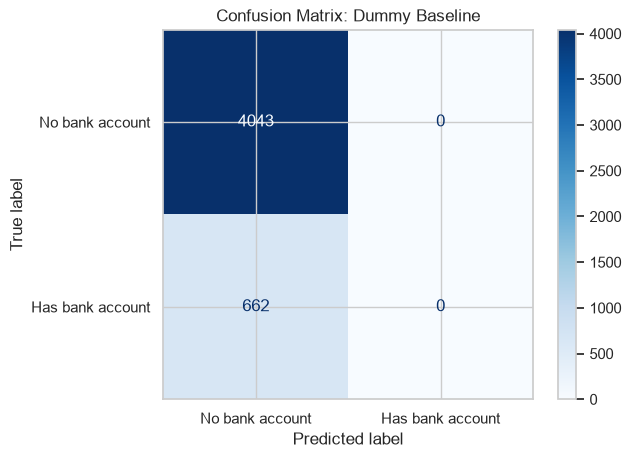

In [65]:
# Confusion Matrix of the baseline model

dummy_confusion_matrix = confusion_matrix(
    y_valid,
    dummy_predictions,
    labels=[0, 1]
)

dummy_display = ConfusionMatrixDisplay(
    confusion_matrix=dummy_confusion_matrix,
    display_labels=["No bank account", "Has bank account"]
)

dummy_display.plot(cmap="Blues")
plt.title("Confusion Matrix: Dummy Baseline")
plt.show()


Bei der Dummy-Baseline:

- Viele True Negatives: Personen ohne Bankkonto werden korrekt erkannt.
- Viele False Negatives: Personen mit Bankkonto werden falsch als „kein Bankkonto“ eingestuft.
- Keine True Positives: Keine Person mit Konto wird korrekt erkannt.
- Keine False Positives: Das Modell sagt nie „hat Konto“.

Erstes echtes Modell: Logistic Regression

Logistic Regression ist ein gutes erstes echtes Modell für binäre Klassifikation:
Sie ist schnell.
Sie ist leicht verständlich.
Sie liefert Wahrscheinlichkeiten.
Sie ist ein guter Vergleichspunkt für komplexere Modelle wie Random Forest oder XGBoost.

In [66]:
logistic_model = LogisticRegression(
    max_iter=1000, # Das Modell bekommt genügend Iteraationen, um eine Lösung zu finden.
    random_state=42 # Ergebnisse bleiben reproduzierbar
)

In [67]:
# Training the model

logistic_model.fit(X_train_prepared, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [68]:
# Prediction of the losgistic regression

logistic_predictions = logistic_model.predict(
    X_valid_prepared
)

In [69]:
print("Logistic Regression predictions:")
print(pd.Series(logistic_predictions).value_counts())

Logistic Regression predictions:
0    4367
1     338
Name: count, dtype: int64


In [70]:
# Logistic Regression

evaluate_model(
    model_name="Logistic Regression",
    y_true=y_valid,
    y_pred=logistic_predictions
)

Model: Logistic Regression
----------------------------------------
Accuracy:          0.889
Balanced accuracy: 0.668
Precision:         0.707
Recall:            0.361
F1 score:          0.478

Classification report:
                  precision    recall  f1-score   support

 No bank account       0.90      0.98      0.94      4043
Has bank account       0.71      0.36      0.48       662

        accuracy                           0.89      4705
       macro avg       0.81      0.67      0.71      4705
    weighted avg       0.88      0.89      0.87      4705



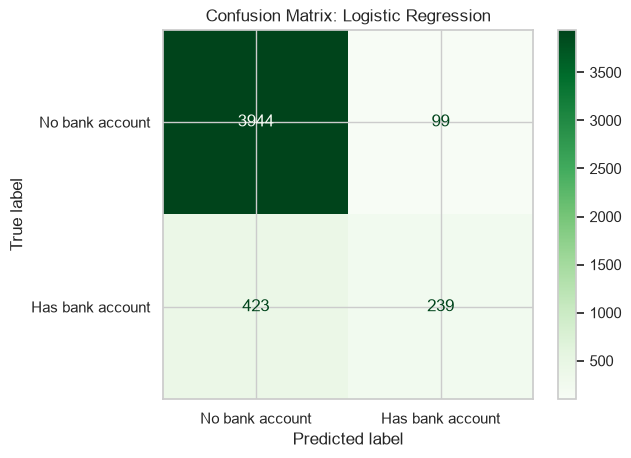

In [71]:
# Confusion matrix of logistic regression

logistic_confusion_matrix = confusion_matrix(
    y_valid,
    logistic_predictions,
    labels=[0, 1]
)

logistic_display = ConfusionMatrixDisplay(
    confusion_matrix=logistic_confusion_matrix,
    display_labels=["No bank account", "Has bank account"]
)

logistic_display.plot(cmap="Greens")
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

In [72]:
# Both models comparison. Dummy Classifier vs Logistic Regression

results = pd.DataFrame(
    {
        "Model": [
            "Dummy Classifier",
            "Logistic Regression"
        ],
        "Accuracy": [
            accuracy_score(y_valid, dummy_predictions),
            accuracy_score(y_valid, logistic_predictions)
        ],
        "Balanced Accuracy": [
            balanced_accuracy_score(y_valid, dummy_predictions),
            balanced_accuracy_score(y_valid, logistic_predictions)
        ],
        "Precision (class 1)": [
            precision_score(
                y_valid,
                dummy_predictions,
                zero_division=0
            ),
            precision_score(
                y_valid,
                logistic_predictions,
                zero_division=0
            )
        ],
        "Recall (class 1)": [
            recall_score(
                y_valid,
                dummy_predictions,
                zero_division=0
            ),
            recall_score(
                y_valid,
                logistic_predictions,
                zero_division=0
            )
        ],
        "F1 Score (class 1)": [
            f1_score(
                y_valid,
                dummy_predictions,
                zero_division=0
            ),
            f1_score(
                y_valid,
                logistic_predictions,
                zero_division=0
            )
        ]
    }
).round(3)

results

# Final predictions on the test set using the logistic regression model

,Model,Accuracy,Balanced Accuracy,Precision (class 1),Recall (class 1),F1 Score (class 1)
0,Dummy Classifier,0.859,0.500,0.000,0.000,0.000
1,Logistic Regression,0.889,0.668,0.707,0.361,0.478


## Baseline Model and Logistic Regression

We first evaluated a Dummy Classifier that always predicts the most frequent class: respondents without a bank account. Although this baseline achieves relatively high accuracy due to class imbalance, it fails to identify any respondents with a bank account.

We then trained a Logistic Regression model as the first machine learning model. Unlike the dummy baseline, Logistic Regression uses demographic, geographic, educational, and employment-related features to estimate whether an individual has or uses a bank account.

Models were evaluated using accuracy, balanced accuracy, precision, recall, F1 score, and confusion matrices. Accuracy is the competition metric, while precision, recall, and F1 score provide additional insight into performance for the minority class: respondents with a bank account.

---

```mermaid
flowchart LR
    A["Business Understanding"] --> B["EDA"]
    B --> C["Feature Engineering"]
    C --> D["Train-Validation Split"]
    D --> E["Preprocessing"]
    E --> F["Baseline & Model Comparison"]
    F --> G["Tuning & Error Analysis"]
    G --> H["Final Model & Stakeholder Presentation"]

    style A fill:#1f6feb,color:#ffffff,stroke:#58a6ff,stroke-width:2px
    style B fill:#1f6feb,color:#ffffff,stroke:#58a6ff,stroke-width:2px
    style C fill:#1f6feb,color:#ffffff,stroke:#58a6ff,stroke-width:2px
    style D fill:#1f6feb,color:#ffffff,stroke:#58a6ff,stroke-width:2px
    style E fill:#1f6feb,color:#ffffff,stroke:#58a6ff,stroke-width:2px

    style F fill:#d29922,color:#ffffff,stroke:#f2cc60,stroke-width:3px

    style G fill:#238636,color:#ffffff,stroke:#3fb950,stroke-width:2px

    style H fill:#8957e5,color:#ffffff,stroke:#b392f0,stroke-width:2px
```

In [73]:
# Import
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

Place preprocessing and Logistic Regression inside one pipeline.
This is important because, during each fold, the preprocessing must be learned from that fold’s training data only.

In [74]:
# Create a model pipeline that includes the preprocessor and the logistic regression model.

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [75]:
# Define the five stratified folds for cross-validation.

# Preserves the target-class distribution in each fold, which is important for imbalances datasets
stratified_kfold = StratifiedKFold(
    n_splits=5, # Creates five folds for cross validation, ensuring that each fold has a similar distribution of the target variable.
    shuffle=True, #Randomly mixes rows before creating folds to reduce bias and improve generalization.
    random_state=42 # MAkes the split reproducible
)

In [76]:
# Select evaluation metrics

scoring_metrics = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

In [77]:
# Run cross-validation
logistic_cv_results = cross_validate(
    estimator=logistic_pipeline,
    X=X_train,
    y=y_train,
    cv=stratified_kfold,
    scoring=scoring_metrics,
    return_train_score=False,
    n_jobs=-1
)

In [78]:
# Display the result of every fold

logistic_cv_scores = pd.DataFrame(
    {
        "Fold": range(1, 6),
        "Accuracy": logistic_cv_results["test_accuracy"],
        "Balanced Accuracy": (
            logistic_cv_results["test_balanced_accuracy"]
        ),
        "Precision": logistic_cv_results["test_precision"],
        "Recall": logistic_cv_results["test_recall"],
        "F1 Score": logistic_cv_results["test_f1"]
    }
).round(3)

logistic_cv_scores

# Each row represents one validation fold

,Fold,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score
0,1,0.883,0.656,0.664,0.340,0.449
1,2,0.887,0.660,0.705,0.343,0.462
2,3,0.888,0.672,0.691,0.372,0.483
3,4,0.876,0.628,0.639,0.281,0.391
4,5,0.885,0.659,0.683,0.345,0.459


In [79]:
# Calculate the average and variability

logistic_cv_summary = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "F1 Score"
        ],
        "Mean Score": [
            logistic_cv_results["test_accuracy"].mean(),
            logistic_cv_results["test_balanced_accuracy"].mean(),
            logistic_cv_results["test_precision"].mean(),
            logistic_cv_results["test_recall"].mean(),
            logistic_cv_results["test_f1"].mean()
        ],
        "Standard Deviation": [
            logistic_cv_results["test_accuracy"].std(),
            logistic_cv_results[
                "test_balanced_accuracy"
            ].std(),
            logistic_cv_results["test_precision"].std(),
            logistic_cv_results["test_recall"].std(),
            logistic_cv_results["test_f1"].std()
        ]
    }
).round(3)

logistic_cv_summary

,Metric,Mean Score,Standard Deviation
0,Accuracy,0.884,0.004
1,Balanced Accuracy,0.655,0.015
2,Precision,0.677,0.023
3,Recall,0.336,0.030
4,F1 Score,0.449,0.031


- Mean Score: Average performance across five folds.
- Standard Deviation: How much performance changes between folds.
- A low standard deviation means the model is relatively stable.
- A high standard deviation means model performance depends strongly on the sampled data.

In [80]:
# Fit the pipline on the full internal training set 

logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['country','year','location_type',...,'marital_status','education_level', 'job_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [81]:
# Evaluate it once on untouched validation dataset

logistic_valid_predictions = logistic_pipeline.predict(X_valid)

In [82]:
evaluate_model(
    model_name="Logistic Regression with 5-Fold CV",
    y_true=y_valid,
    y_pred=logistic_valid_predictions
)

Model: Logistic Regression with 5-Fold CV
----------------------------------------
Accuracy:          0.889
Balanced accuracy: 0.668
Precision:         0.707
Recall:            0.361
F1 score:          0.478

Classification report:
                  precision    recall  f1-score   support

 No bank account       0.90      0.98      0.94      4043
Has bank account       0.71      0.36      0.48       662

        accuracy                           0.89      4705
       macro avg       0.81      0.67      0.71      4705
    weighted avg       0.88      0.89      0.87      4705



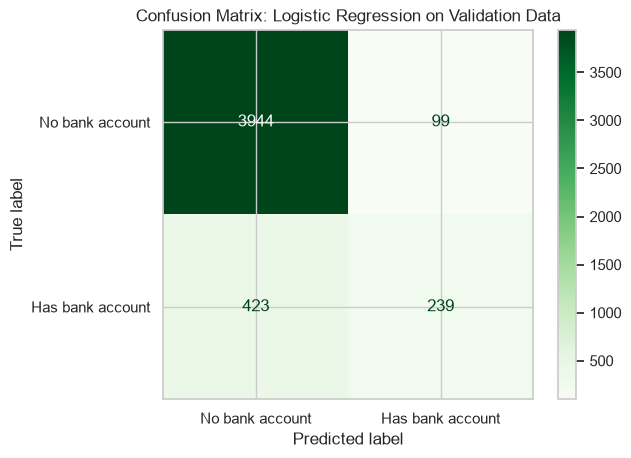

In [83]:
# Create a confusion matrix for logistic regression with cross validation!

logistic_valid_cm = confusion_matrix(
    y_valid,
    logistic_valid_predictions,
    labels=[0, 1]
)

logistic_valid_display = ConfusionMatrixDisplay(
    confusion_matrix=logistic_valid_cm,
    display_labels=["No bank account", "Has bank account"]
)

logistic_valid_display.plot(cmap="Greens")
plt.title(
    "Confusion Matrix: Logistic Regression on Validation Data"
)
plt.show()

This is now my reliable Logistic regression benchmark

## Logistic Regression Cross-Validation

To obtain a more reliable estimate of model performance, we applied five-fold stratified cross-validation to the Logistic Regression model. Stratification was used because the target variable is imbalanced: respondents without a bank account represent the majority class.

The preprocessing pipeline was included inside the cross-validation process. This ensures that imputation, scaling, and one-hot encoding are fitted only on each fold’s training portion, preventing data leakage.

We evaluated accuracy, balanced accuracy, precision, recall, and F1 score. After cross-validation, the Logistic Regression model was fitted on the complete internal training set and evaluated on the held-out validation set.

---

Does a more flexible machine-learning algorithm perform better than our Logistic Regression benchmark?

We have already created:
- A Dummy Classifier as the minimum baseline
- A Logistic Regression model as the first real ML model
- A preprocessing pipeline
- Stratified cross-validation

## Random Forest Model

In [84]:
# Import Random Forest

from sklearn.ensemble import RandomForestClassifier

In [85]:
# Create the model pipeline 

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=1
            )
        )
    ]
)

n_estimators=300 means that the Random Forest builds 300 decision trees.

Each tree learns slightly different rules from a random sample of observations and features. The final classification is based on the combined decisions of all trees.
random_state=42 makes the result reproducible.

n_jobs=1 means that each individual Random Forest uses one CPU core. We use this setting because the cross-validation process itself will already run folds in parallel with n_jobs=-1

In [86]:
# Cross-Validate the random forest

stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [87]:
scoring_metrics = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

This process performs the following steps five times:
- Create a stratified training fold.
- Learn preprocessing only from that fold.
- Train 300 decision trees.
- Transform the corresponding evaluation fold.
- Predict the target.
- Calculate all evaluation metrics.
- The model never sees a fold’s target values during its training phase.

In [88]:
random_forest_cv_results = cross_validate(
    estimator=random_forest_pipeline,
    X=X_train,
    y=y_train,
    cv=stratified_kfold,
    scoring=scoring_metrics,
    return_train_score=False,
    n_jobs=-1
)

In [89]:
# Inspect every Cross-Validation Fold

random_forest_cv_scores = pd.DataFrame(
    {
        "Fold": range(1, 6),
        "Accuracy": random_forest_cv_results["test_accuracy"],
        "Balanced Accuracy": (
            random_forest_cv_results["test_balanced_accuracy"]
        ),
        "Precision": random_forest_cv_results["test_precision"],
        "Recall": random_forest_cv_results["test_recall"],
        "F1 Score": random_forest_cv_results["test_f1"]
    }
).round(3)

random_forest_cv_scores

,Fold,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score
0,1,0.869,0.668,0.551,0.389,0.456
1,2,0.858,0.645,0.495,0.349,0.409
2,3,0.863,0.662,0.521,0.381,0.440
3,4,0.850,0.640,0.455,0.347,0.394
4,5,0.866,0.674,0.531,0.408,0.461


In [90]:
# Calculate the average random forest performance

random_forest_cv_summary = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "F1 Score"
        ],
        "Mean Score": [
            random_forest_cv_results["test_accuracy"].mean(),
            random_forest_cv_results[
                "test_balanced_accuracy"
            ].mean(),
            random_forest_cv_results["test_precision"].mean(),
            random_forest_cv_results["test_recall"].mean(),
            random_forest_cv_results["test_f1"].mean()
        ],
        "Standard Deviation": [
            random_forest_cv_results["test_accuracy"].std(),
            random_forest_cv_results[
                "test_balanced_accuracy"
            ].std(),
            random_forest_cv_results["test_precision"].std(),
            random_forest_cv_results["test_recall"].std(),
            random_forest_cv_results["test_f1"].std()
        ]
    }
).round(3)

random_forest_cv_summary

,Metric,Mean Score,Standard Deviation
0,Accuracy,0.861,0.007
1,Balanced Accuracy,0.658,0.013
2,Precision,0.510,0.033
3,Recall,0.375,0.023
4,F1 Score,0.432,0.026


In [91]:
# Compare Logistic Regression and Random Forest

model_comparison = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Random Forest"
        ],
        "Accuracy": [
            logistic_cv_results["test_accuracy"].mean(),
            random_forest_cv_results["test_accuracy"].mean()
        ],
        "Balanced Accuracy": [
            logistic_cv_results[
                "test_balanced_accuracy"
            ].mean(),
            random_forest_cv_results[
                "test_balanced_accuracy"
            ].mean()
        ],
        "Precision": [
            logistic_cv_results["test_precision"].mean(),
            random_forest_cv_results["test_precision"].mean()
        ],
        "Recall": [
            logistic_cv_results["test_recall"].mean(),
            random_forest_cv_results["test_recall"].mean()
        ],
        "F1 Score": [
            logistic_cv_results["test_f1"].mean(),
            random_forest_cv_results["test_f1"].mean()
        ]
    }
).round(3)

model_comparison

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.884,0.655,0.677,0.336,0.449
1,Random Forest,0.861,0.658,0.510,0.375,0.432


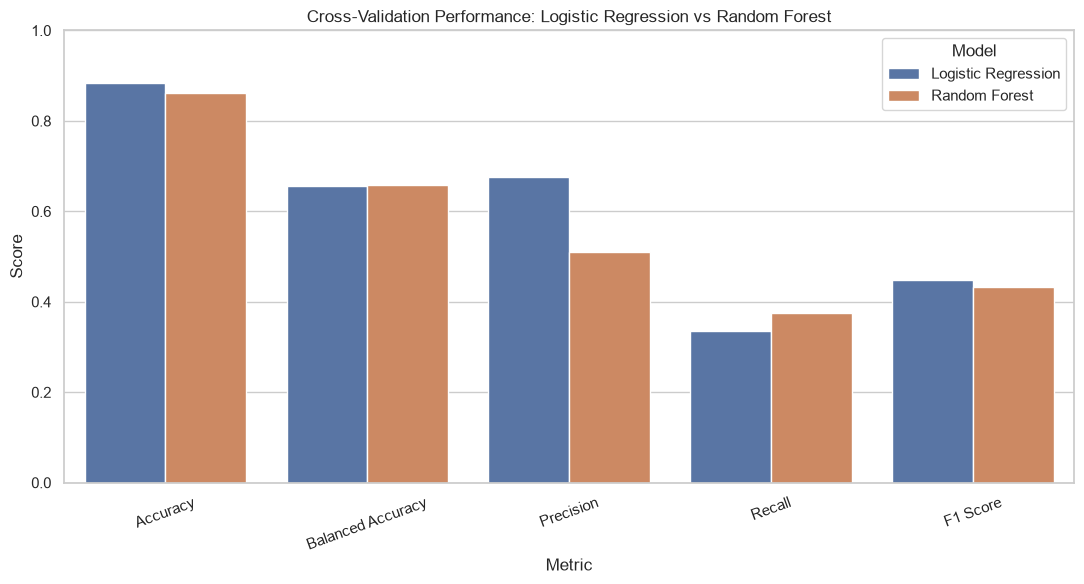

In [92]:
comparison_long = model_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title(
    "Cross-Validation Performance: "
    "Logistic Regression vs Random Forest"
)
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

Random Forest makes more correct predictions overall.

Logistic Regression detects more people belonging to the positive class.

## Random Forest Model

A Random Forest classifier was trained as the second machine-learning algorithm. Unlike Logistic Regression, Random Forest can capture nonlinear relationships and interactions between variables.

The model was evaluated using the same five-fold stratified cross-validation procedure as Logistic Regression. Using identical folds, preprocessing steps, and evaluation metrics ensures a fair comparison between the algorithms.

Accuracy and error rate were considered because they represent the original competition metric. Balanced accuracy, precision, recall, and F1 score were also evaluated because the target variable is imbalanced. The final model will not be selected until the third algorithm has also been evaluated.

---

### Model Comparison - Third Algo --> Gradient Boosting



Gradient Boosting is useful because it builds decision trees sequentially. Each new tree attempts to correct mistakes made by the previous trees.

In [93]:
# Import

from sklearn.ensemble import GradientBoostingClassifier

Create a dense One-Hot Encoder

GradientBoostingClassifier requires a dense numerical matrix. The previous preprocessing pipeline may produce a sparse matrix because of One-Hot-Encoding.

In [94]:
try:
    dense_one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    # Compatibility with older Scikit-learn versions
    dense_one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

In [95]:
# Create a categorical transformer

dense_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "one_hot_encoder",
            dense_one_hot_encoder
        )
    ]
)

In [96]:
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [97]:
dense_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            dense_categorical_transformer,
            categorical_features
        )
    ]
)

In [98]:
# Create the gradient boosting pipeline

gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", dense_preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=150,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

- n_estimators=150: The model builds 150 sequential trees.
- learning_rate=0.05: Controls how strongly each tree changes the model.
- max_depth=3: Limits the complexity of each tree.

In [99]:
# Run five-fold stratified cross-validation

gradient_boosting_cv_results = cross_validate(
    estimator=gradient_boosting_pipeline,
    X=X_train,
    y=y_train,
    cv=stratified_kfold,
    scoring=scoring_metrics,
    return_train_score=False,
    n_jobs=-1
)

In [100]:
# Display the results for each fold

gradient_boosting_cv_scores = pd.DataFrame(
    {
        "Fold": range(1, 6),
        "Accuracy": (
            gradient_boosting_cv_results["test_accuracy"]
        ),
        "Balanced Accuracy": (
            gradient_boosting_cv_results[
                "test_balanced_accuracy"
            ]
        ),
        "Precision": (
            gradient_boosting_cv_results["test_precision"]
        ),
        "Recall": (
            gradient_boosting_cv_results["test_recall"]
        ),
        "F1 Score": (
            gradient_boosting_cv_results["test_f1"]
        )
    }
).round(3)

gradient_boosting_cv_scores

,Fold,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score
0,1,0.889,0.652,0.747,0.323,0.451
1,2,0.889,0.649,0.759,0.315,0.445
2,3,0.891,0.663,0.741,0.345,0.471
3,4,0.881,0.631,0.688,0.283,0.401
4,5,0.888,0.655,0.720,0.330,0.453


In [101]:
gradient_boosting_cv_summary = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "F1 Score"
        ],
        "Mean Score": [
            gradient_boosting_cv_results[
                "test_accuracy"
            ].mean(),
            gradient_boosting_cv_results[
                "test_balanced_accuracy"
            ].mean(),
            gradient_boosting_cv_results[
                "test_precision"
            ].mean(),
            gradient_boosting_cv_results[
                "test_recall"
            ].mean(),
            gradient_boosting_cv_results[
                "test_f1"
            ].mean()
        ],
        "Standard Deviation": [
            gradient_boosting_cv_results[
                "test_accuracy"
            ].std(),
            gradient_boosting_cv_results[
                "test_balanced_accuracy"
            ].std(),
            gradient_boosting_cv_results[
                "test_precision"
            ].std(),
            gradient_boosting_cv_results[
                "test_recall"
            ].std(),
            gradient_boosting_cv_results[
                "test_f1"
            ].std()
        ]
    }
).round(3)

gradient_boosting_cv_summary

,Metric,Mean Score,Standard Deviation
0,Accuracy,0.888,0.003
1,Balanced Accuracy,0.650,0.010
2,Precision,0.731,0.025
3,Recall,0.319,0.021
4,F1 Score,0.444,0.023


In [102]:
model_comparison = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Random Forest",
            "Gradient Boosting"
        ],
        "Accuracy": [
            logistic_cv_results[
                "test_accuracy"
            ].mean(),
            random_forest_cv_results[
                "test_accuracy"
            ].mean(),
            gradient_boosting_cv_results[
                "test_accuracy"
            ].mean()
        ],
        "Balanced Accuracy": [
            logistic_cv_results[
                "test_balanced_accuracy"
            ].mean(),
            random_forest_cv_results[
                "test_balanced_accuracy"
            ].mean(),
            gradient_boosting_cv_results[
                "test_balanced_accuracy"
            ].mean()
        ],
        "Precision": [
            logistic_cv_results[
                "test_precision"
            ].mean(),
            random_forest_cv_results[
                "test_precision"
            ].mean(),
            gradient_boosting_cv_results[
                "test_precision"
            ].mean()
        ],
        "Recall": [
            logistic_cv_results[
                "test_recall"
            ].mean(),
            random_forest_cv_results[
                "test_recall"
            ].mean(),
            gradient_boosting_cv_results[
                "test_recall"
            ].mean()
        ],
        "F1 Score": [
            logistic_cv_results[
                "test_f1"
            ].mean(),
            random_forest_cv_results[
                "test_f1"
            ].mean(),
            gradient_boosting_cv_results[
                "test_f1"
            ].mean()
        ]
    }
).round(3)

model_comparison["Error Rate"] = (
    1 - model_comparison["Accuracy"]
).round(3)

model_comparison

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Error Rate
0,Logistic Regression,0.884,0.655,0.677,0.336,0.449,0.116
1,Random Forest,0.861,0.658,0.510,0.375,0.432,0.139
2,Gradient Boosting,0.888,0.650,0.731,0.319,0.444,0.112


In [103]:
model_comparison.sort_values(
    by="Error Rate",
    ascending=True
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Error Rate
2,Gradient Boosting,0.888,0.650,0.731,0.319,0.444,0.112
0,Logistic Regression,0.884,0.655,0.677,0.336,0.449,0.116
1,Random Forest,0.861,0.658,0.510,0.375,0.432,0.139


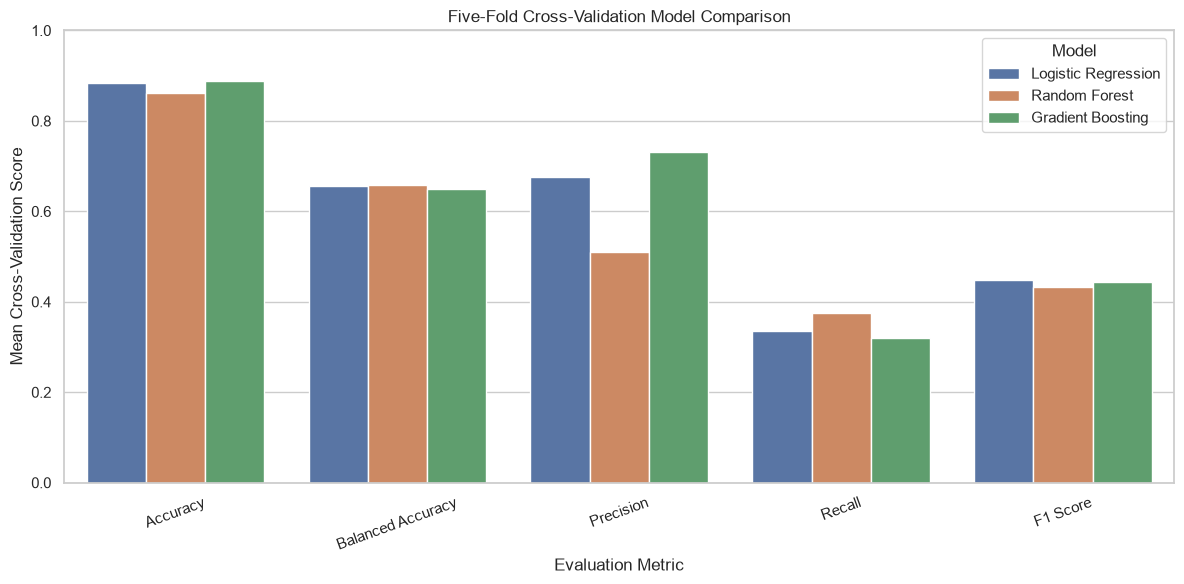

In [104]:
metrics_to_plot = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

comparison_long = model_comparison.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Five-Fold Cross-Validation Model Comparison")
plt.ylabel("Mean Cross-Validation Score")
plt.xlabel("Evaluation Metric")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

## Gradient Boosting Model

Gradient Boosting was evaluated as the third machine-learning algorithm. Unlike Random Forest, which builds trees independently, Gradient Boosting builds trees sequentially. Each new tree attempts to correct errors made by the previous trees.

The model was evaluated using the same five-fold stratified cross-validation procedure and the same evaluation metrics as Logistic Regression and Random Forest. A dense preprocessing pipeline was used because the Scikit-learn Gradient Boosting implementation requires a dense numerical feature matrix.

The three algorithms were compared using accuracy, error rate, balanced accuracy, precision, recall, and F1 score. Accuracy and error rate represent the original competition objective, while the additional metrics help assess performance on the minority class.

---

### Hyperparameter Tuning



In [105]:
# Selecting the best model from cross-validation

model_comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Error Rate
2,Gradient Boosting,0.888,0.650,0.731,0.319,0.444,0.112
0,Logistic Regression,0.884,0.655,0.677,0.336,0.449,0.116
1,Random Forest,0.861,0.658,0.510,0.375,0.432,0.139


In [106]:
best_model_name = (
    model_comparison
    .sort_values(by="Accuracy", ascending=False)
    .iloc[0]["Model"]
)

print("Model selected for tuning:", best_model_name)

Model selected for tuning: Gradient Boosting


Gradient Boosting is the best model according to the competition metric:

- Highest Accuracy: 0.888
- Lowest error rate: 0.112
- Highest Precision: 0.731

However, Logistic Regression still has slightly better Balanced Accuracy, Recall, and F1 Score. Therefore, our precise conclusion is:

Gradient Boosting is the leading model for the competition objective, but it is not the strongest model for identifying the largest possible number of bank-account holders.


Why use RandomizedSearchCV?

A full grid search would test every possible combination. With six or seven hyperparameters, that can become computationally expensive.

RandomizedSearchCV tests a fixed number of randomly selected combinations. It is usually more efficient for an initial tuning experiment.

In [107]:
# Import RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

In [108]:
gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", dense_preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=150,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

In [109]:
# Define the parameter search space

gradient_boosting_parameter_space = {
    "model__n_estimators": [
        100,
        150,
        200,
        250,
        300
    ],
    "model__learning_rate": [
        0.02,
        0.05,
        0.08,
        0.10,
        0.15
    ],
    "model__max_depth": [
        2,
        3,
        4,
        5
    ],
    "model__min_samples_split": [
        2,
        5,
        10,
        20
    ],
    "model__min_samples_leaf": [
        1,
        2,
        5,
        10,
        20
    ],
    "model__subsample": [
        0.70,
        0.85,
        1.00
    ],
    "model__max_features": [
        None,
        "sqrt",
        "log2"
    ]
}

In [110]:
# Create the randomized search

gradient_boosting_search = RandomizedSearchCV(
    estimator=gradient_boosting_pipeline,
    param_distributions=gradient_boosting_parameter_space,
    n_iter=30,
    scoring=scoring_metrics,
    refit="accuracy",
    cv=stratified_kfold,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

In [111]:
gradient_boosting_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END model__learning_rate=0.15, model__max_depth=3, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=100, model__subsample=0.7; total time=   0.4s
[CV] END model__learning_rate=0.02, model__max_depth=2, model__max_features=log2, model__min_samples_leaf=20, model__min_samples_split=5, model__n_estimators=150, model__subsample=1.0; total time=   0.4s
[CV] END model__learning_rate=0.15, model__max_depth=3, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=100, model__subsample=0.7; total time=   0.4s
[CV] END model__learning_rate=0.15, model__max_depth=3, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=100, model__subsample=0.7; total time=   0.4s
[CV] END model__learning_rate=0.15, model__max_depth=3, model__max_features=sqrt, model__min_samples_leaf=10, model__min_s

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.02, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__max_features': [None, 'sqrt', ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'f1': 'f1', 'precision': 'precision', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`Stratifie

In [112]:
#Display the best parameters

print("Best parameters:")

for parameter, value in gradient_boosting_search.best_params_.items():
    print(f"{parameter}: {value}")

Best parameters:
model__subsample: 1.0
model__n_estimators: 150
model__min_samples_split: 20
model__min_samples_leaf: 1
model__max_features: log2
model__max_depth: 4
model__learning_rate: 0.15


In [113]:
# Display the best cross-validation Accuracy

print(
    "Best mean cross-validation Accuracy:",
    round(gradient_boosting_search.best_score_, 3)
)

print(
    "Best mean cross-validation error rate:",
    round(1 - gradient_boosting_search.best_score_, 3)
)

Best mean cross-validation Accuracy: 0.889
Best mean cross-validation error rate: 0.111


In [114]:
# Comparison with the original Gradient Boosting

untuned_gradient_accuracy = (
    gradient_boosting_cv_results["test_accuracy"].mean()
)

tuned_gradient_accuracy = (
    gradient_boosting_search.best_score_
)

print(
    "Untuned Gradient Boosting Accuracy:",
    round(untuned_gradient_accuracy, 3)
)

print(
    "Tuned Gradient Boosting Accuracy:",
    round(tuned_gradient_accuracy, 3)
)

print(
    "Accuracy improvement:",
    round(
        tuned_gradient_accuracy - untuned_gradient_accuracy,
        4
    )
)

Untuned Gradient Boosting Accuracy: 0.888
Tuned Gradient Boosting Accuracy: 0.889
Accuracy improvement: 0.0013


Examine the best search results

In [115]:
tuning_results = pd.DataFrame(
    gradient_boosting_search.cv_results_
)

In [116]:
# Selecting the most useful columns

tuning_summary = tuning_results[
    [
        "rank_test_accuracy",
        "mean_train_accuracy",
        "mean_test_accuracy",
        "std_test_accuracy",
        "mean_test_balanced_accuracy",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_f1",
        "params"
    ]
].sort_values(
    by="rank_test_accuracy"
)

tuning_summary.head(10)

# This shows the ten best parameter combinations according to accuracy.

,rank_test_accuracy,mean_train_accuracy,mean_test_accuracy,std_test_accuracy,mean_test_balanced_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,params
6,1,0.896886,0.888942,0.003800,0.673180,0.697518,0.372830,0.485851,"{'model__subsample': 1.0, 'model__n_estimators..."
11,2,0.895863,0.888676,0.003926,0.669397,0.701272,0.364151,0.479184,"{'model__subsample': 0.7, 'model__n_estimators..."
0,3,0.890669,0.888358,0.004298,0.661008,0.714225,0.344528,0.464683,"{'model__subsample': 0.7, 'model__n_estimators..."
3,4,0.895425,0.888145,0.003501,0.668457,0.697326,0.362642,0.477005,"{'model__subsample': 0.7, 'model__n_estimators..."
24,5,0.892449,0.888145,0.003264,0.650946,0.735428,0.320755,0.446584,"{'model__subsample': 0.7, 'model__n_estimators..."
16,6,0.890084,0.888092,0.003287,0.655647,0.723193,0.332075,0.455034,"{'model__subsample': 1.0, 'model__n_estimators..."
8,7,0.891121,0.887879,0.003147,0.660730,0.709598,0.344528,0.463676,"{'model__subsample': 1.0, 'model__n_estimators..."
17,8,0.896474,0.887720,0.004160,0.658271,0.712301,0.338868,0.459070,"{'model__subsample': 0.7, 'model__n_estimators..."
2,9,0.889101,0.887720,0.003227,0.644861,0.746129,0.306792,0.434582,"{'model__subsample': 1.0, 'model__n_estimators..."
20,10,0.891546,0.887667,0.003549,0.662341,0.703694,0.348679,0.466208,"{'model__subsample': 1.0, 'model__n_estimators..."


In [117]:
# Inspect the best model's complete metric profile

best_result = tuning_summary.iloc[0]

print("Best tuned Gradient Boosting model")
print("-" * 45)

print(
    "Mean training Accuracy:",
    round(best_result["mean_train_accuracy"], 3)
)

print(
    "Mean CV Accuracy:",
    round(best_result["mean_test_accuracy"], 3)
)

print(
    "CV Accuracy standard deviation:",
    round(best_result["std_test_accuracy"], 3)
)

print(
    "Mean CV Balanced Accuracy:",
    round(
        best_result["mean_test_balanced_accuracy"],
        3
    )
)

print(
    "Mean CV Precision:",
    round(best_result["mean_test_precision"], 3)
)

print(
    "Mean CV Recall:",
    round(best_result["mean_test_recall"], 3)
)

print(
    "Mean CV F1 Score:",
    round(best_result["mean_test_f1"], 3)
)

Best tuned Gradient Boosting model
---------------------------------------------
Mean training Accuracy: 0.897
Mean CV Accuracy: 0.889
CV Accuracy standard deviation: 0.004
Mean CV Balanced Accuracy: 0.673
Mean CV Precision: 0.698
Mean CV Recall: 0.373
Mean CV F1 Score: 0.486


In [118]:
# Check for overfitting

training_accuracy = best_result["mean_train_accuracy"]
cross_validation_accuracy = best_result["mean_test_accuracy"]

accuracy_gap = training_accuracy - cross_validation_accuracy

print(
    "Train-CV Accuracy gap:",
    round(accuracy_gap, 3)
)

Train-CV Accuracy gap: 0.008


Small gap: model generalises reasonably well.

#### Retrieve the best model

In [119]:
refit="accuracy"

In [120]:
best_gradient_boosting_model = (
    gradient_boosting_search.best_estimator_
)

In [121]:
tuned_validation_predictions = (
    best_gradient_boosting_model.predict(X_valid)
)

In [122]:
tuned_validation_probabilities = (
    best_gradient_boosting_model.predict_proba(X_valid)[:, 1]
)


In [123]:
evaluate_model(
    model_name="Tuned Gradient Boosting",
    y_true=y_valid,
    y_pred=tuned_validation_predictions
)

Model: Tuned Gradient Boosting
----------------------------------------
Accuracy:          0.889
Balanced accuracy: 0.679
Precision:         0.690
Recall:            0.387
F1 score:          0.496

Classification report:
                  precision    recall  f1-score   support

 No bank account       0.91      0.97      0.94      4043
Has bank account       0.69      0.39      0.50       662

        accuracy                           0.89      4705
       macro avg       0.80      0.68      0.72      4705
    weighted avg       0.88      0.89      0.88      4705



In [124]:
validation_accuracy = accuracy_score(
    y_valid,
    tuned_validation_predictions
)

validation_error_rate = 1 - validation_accuracy

print(
    "Validation Accuracy:",
    round(validation_accuracy, 3)
)

print(
    "Validation error rate:",
    round(validation_error_rate, 3)
)

Validation Accuracy: 0.889
Validation error rate: 0.111


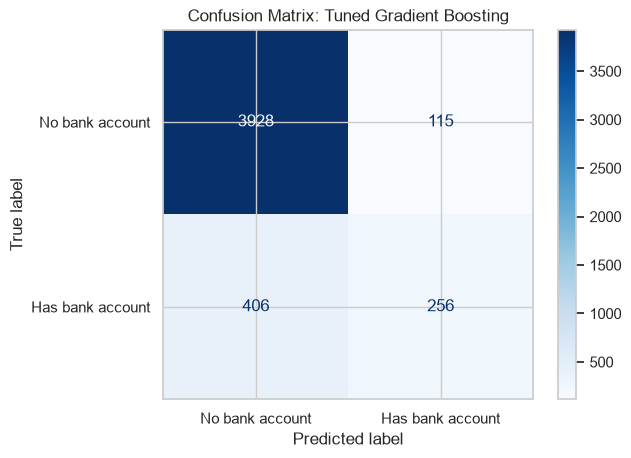

In [125]:
# Display the final validation confusion matrix

tuned_validation_cm = confusion_matrix(
    y_valid,
    tuned_validation_predictions,
    labels=[0, 1]
)

tuned_validation_display = ConfusionMatrixDisplay(
    confusion_matrix=tuned_validation_cm,
    display_labels=[
        "No bank account",
        "Has bank account"
    ]
)

tuned_validation_display.plot(cmap="Blues")

plt.title(
    "Confusion Matrix: Tuned Gradient Boosting"
)

plt.show()

In [126]:
# Compare cross-validation and held-out validation performance 

final_validation_comparison = pd.DataFrame(
    {
        "Evaluation": [
            "Tuned cross-validation",
            "Held-out validation"
        ],
        "Accuracy": [
            gradient_boosting_search.best_score_,
            accuracy_score(
                y_valid,
                tuned_validation_predictions
            )
        ],
        "Balanced Accuracy": [
            best_result[
                "mean_test_balanced_accuracy"
            ],
            balanced_accuracy_score(
                y_valid,
                tuned_validation_predictions
            )
        ],
        "Precision": [
            best_result["mean_test_precision"],
            precision_score(
                y_valid,
                tuned_validation_predictions,
                zero_division=0
            )
        ],
        "Recall": [
            best_result["mean_test_recall"],
            recall_score(
                y_valid,
                tuned_validation_predictions,
                zero_division=0
            )
        ],
        "F1 Score": [
            best_result["mean_test_f1"],
            f1_score(
                y_valid,
                tuned_validation_predictions,
                zero_division=0
            )
        ]
    }
).round(3)

final_validation_comparison

,Evaluation,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score
0,Tuned cross-validation,0.889,0.673,0.698,0.373,0.486
1,Held-out validation,0.889,0.679,0.690,0.387,0.496


The held-out results are close to the cross-validation results, so the model likely generalises well.

## Gradient Boosting Hyperparameter Tuning

Gradient Boosting achieved the highest cross-validation accuracy and the lowest classification error among the three evaluated algorithms. It was therefore selected for hyperparameter tuning according to the original competition objective.

Randomized search with five-fold stratified cross-validation was used to evaluate 30 parameter combinations. The search covered the number of estimators, learning rate, tree depth, minimum split and leaf sizes, subsampling rate, and number of features considered at each split.

Accuracy was used as the model-selection metric, while balanced accuracy, precision, recall, and F1 score were monitored to assess performance on the minority class. All preprocessing was included inside the pipeline and fitted independently within each cross-validation fold to prevent data leakage.

After tuning, the selected model was evaluated on the held-out validation set. This dataset was not used during cross-validation or hyperparameter selection and therefore provides an estimate of performance on unseen labelled data.

---

## Error Analysis

Error analysis answers a different question from model evaluation:

Where does the model fail, what kinds of mistakes does it make, and which population groups are affected?

This is important because a single Accuracy score cannot show whether errors are concentrated in particular countries, education groups, age groups, or genders.


In [127]:
# Create an error-analysis DataFrame

error_analysis = X_valid.copy()

error_analysis["actual"] = y_valid
error_analysis["predicted"] = tuned_validation_predictions
error_analysis["predicted_probability"] = (
    tuned_validation_probabilities
)

error_analysis.head()

,country,year,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,actual,predicted,predicted_probability
69,Kenya,2018,Urban,Yes,1,30,Male,Head of Household,Single/Never Married,Secondary education,Formally employed Private,1,1,0.698046
13395,Rwanda,2016,Urban,Yes,4,30,Female,Spouse,Married/Living together,Primary education,Remittance Dependent,0,0,0.146209
18888,Tanzania,2017,Urban,Yes,1,34,Female,Head of Household,Married/Living together,No formal education,Self employed,0,0,0.020245
4660,Kenya,2018,Rural,No,7,45,Female,Spouse,Married/Living together,Primary education,Informally employed,0,0,0.013923
13090,Rwanda,2016,Rural,Yes,5,35,Female,Spouse,Married/Living together,Primary education,Farming and Fishing,0,0,0.075102


Each row now contains:

- Original respondent characteristics
- Actual target
- Predicted target
- Predicted probability of having a bank account

In [128]:
# Add readable labels

target_labels = {
    0: "No bank account",
    1: "Has bank account"
}

error_analysis["actual_label"] = (
    error_analysis["actual"].map(target_labels)
)

error_analysis["predicted_label"] = (
    error_analysis["predicted"].map(target_labels)
)



In [129]:
# Classify every prediction by error type

conditions = [
    (
        (error_analysis["actual"] == 0)
        & (error_analysis["predicted"] == 0)
    ),
    (
        (error_analysis["actual"] == 0)
        & (error_analysis["predicted"] == 1)
    ),
    (
        (error_analysis["actual"] == 1)
        & (error_analysis["predicted"] == 0)
    ),
    (
        (error_analysis["actual"] == 1)
        & (error_analysis["predicted"] == 1)
    )
]

error_types = [
    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive"
]

error_analysis["error_type"] = np.select(
    conditions,
    error_types,
    default="Unknown"
)

In [130]:
error_analysis[
    [
        "actual_label",
        "predicted_label",
        "predicted_probability",
        "error_type"
    ]
].head(10)

,actual_label,predicted_label,predicted_probability,error_type
69,Has bank account,Has bank account,0.698046,True Positive
13395,No bank account,No bank account,0.146209,True Negative
18888,No bank account,No bank account,0.020245,True Negative
4660,No bank account,No bank account,0.013923,True Negative
13090,No bank account,No bank account,0.075102,True Negative
13444,No bank account,No bank account,0.381761,True Negative
15565,No bank account,No bank account,0.015251,True Negative
6723,No bank account,No bank account,0.096662,True Negative
13409,No bank account,No bank account,0.036977,True Negative
8427,No bank account,No bank account,0.032503,True Negative


In [131]:
# count the four prediction outcomes

error_counts = (
    error_analysis["error_type"]
    .value_counts()
    .reindex(error_types)
)

error_counts

error_type
True Negative     3928
False Positive     115
False Negative     406
True Positive      256
Name: count, dtype: int64

In [132]:
# Calculate percentages

error_percentages = (
    error_analysis["error_type"]
    .value_counts(normalize=True)
    .reindex(error_types)
    .mul(100)
    .round(2)
)

error_summary = pd.DataFrame(
    {
        "Count": error_counts,
        "Percentage": error_percentages
    }
)

error_summary

,Count,Percentage
error_type,,
True Negative,3928,83.49
False Positive,115,2.44
False Negative,406,8.63
True Positive,256,5.44


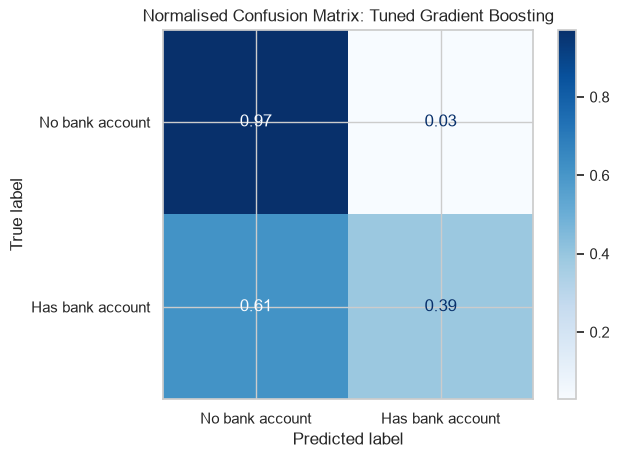

In [133]:
# Normalised confusion matrix

normalised_cm = confusion_matrix(
    y_valid,
    tuned_validation_predictions,
    labels=[0, 1],
    normalize="true"
)

normalised_display = ConfusionMatrixDisplay(
    confusion_matrix=normalised_cm,
    display_labels=[
        "No bank account",
        "Has bank account"
    ]
)

normalised_display.plot(
    cmap="Blues",
    values_format=".2f"
)

plt.title(
    "Normalised Confusion Matrix: "
    "Tuned Gradient Boosting"
)

plt.show()

In [134]:
false_positives = error_analysis[
    error_analysis["error_type"] == "False Positive"
].copy()

false_negatives = error_analysis[
    error_analysis["error_type"] == "False Negative"
].copy()

In [135]:
print(
    "Number of false positives:",
    len(false_positives)
)

print(
    "Number of false negatives:",
    len(false_negatives)
)

Number of false positives: 115
Number of false negatives: 406


In [136]:
# Inspect false positives - These are people for whom the model predicted a high probability of owning an account even though the actual answer was No.

false_positives[
    [
        "country",
        "location_type",
        "cellphone_access",
        "age_of_respondent",
        "gender_of_respondent",
        "education_level",
        "job_type",
        "predicted_probability"
    ]
].sort_values(
    by="predicted_probability",
    ascending=False
).head(5)

,country,location_type,cellphone_access,age_of_respondent,gender_of_respondent,education_level,job_type,predicted_probability
11547,Rwanda,Urban,Yes,42,Male,Tertiary education,Formally employed Private,0.936859
864,Kenya,Urban,Yes,25,Male,Tertiary education,Formally employed Government,0.928444
5839,Kenya,Urban,Yes,46,Male,Vocational/Specialised training,Formally employed Government,0.927253
2248,Kenya,Urban,Yes,27,Male,Tertiary education,Formally employed Private,0.924968
14300,Rwanda,Urban,Yes,30,Male,Tertiary education,Formally employed Government,0.921844


In [137]:
# Inspect false negatives - These are actual account holders whom the model classifies as not having an account

false_negatives[
    [
        "country",
        "location_type",
        "cellphone_access",
        "age_of_respondent",
        "gender_of_respondent",
        "education_level",
        "job_type",
        "predicted_probability"
    ]
].sort_values(
    by="predicted_probability",
    ascending=True
).head(10)

,country,location_type,cellphone_access,age_of_respondent,gender_of_respondent,education_level,job_type,predicted_probability
17261,Tanzania,Urban,No,26,Female,Primary education,Remittance Dependent,0.002434
104,Kenya,Urban,No,16,Female,Secondary education,Remittance Dependent,0.009067
10325,Rwanda,Urban,No,19,Male,Secondary education,Remittance Dependent,0.012683
3520,Kenya,Urban,No,29,Female,Primary education,Informally employed,0.012859
16125,Tanzania,Urban,Yes,80,Female,No formal education,Self employed,0.014111
17588,Tanzania,Urban,Yes,23,Male,No formal education,Informally employed,0.017941
6459,Rwanda,Rural,Yes,16,Male,Primary education,Farming and Fishing,0.018838
23351,Uganda,Rural,Yes,36,Female,Primary education,No Income,0.019578
23362,Uganda,Urban,No,18,Female,Secondary education,Other Income,0.023462
17968,Tanzania,Urban,Yes,33,Male,No formal education,Self employed,0.029335


In [138]:
# Analyse prediction confidence

error_analysis["prediction_confidence"] = np.where(
    error_analysis["predicted"] == 1,
    error_analysis["predicted_probability"],
    1 - error_analysis["predicted_probability"]
)

In [139]:
error_analysis["is_error"] = (
    error_analysis["actual"]
    != error_analysis["predicted"]
)

In [140]:
# Compare confidence for correct and incorrect predictions

confidence_summary = (
    error_analysis
    .groupby("is_error")["prediction_confidence"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(3)
)

confidence_summary

,count,mean,median,min,max
is_error,,,,,
False,4184,0.908,0.946,0.501,1.000
True,521,0.753,0.766,0.500,0.998


In [141]:
confidence_summary.index = [
    "Correct prediction",
    "Incorrect prediction"
]

confidence_summary

,count,mean,median,min,max
Correct prediction,4184,0.908,0.946,0.501,1.000
Incorrect prediction,521,0.753,0.766,0.500,0.998


In [142]:
# Finding high-confidence mistakes

high_confidence_errors = error_analysis[
    error_analysis["is_error"]
].sort_values(
    by="prediction_confidence",
    ascending=False
)

In [143]:
high_confidence_errors[
    [
        "country",
        "location_type",
        "cellphone_access",
        "age_of_respondent",
        "gender_of_respondent",
        "education_level",
        "job_type",
        "actual_label",
        "predicted_label",
        "predicted_probability",
        "prediction_confidence",
        "error_type"
    ]
].head(10)

,country,location_type,cellphone_access,age_of_respondent,gender_of_respondent,education_level,job_type,actual_label,predicted_label,predicted_probability,prediction_confidence,error_type
17261,Tanzania,Urban,No,26,Female,Primary education,Remittance Dependent,Has bank account,No bank account,0.002434,0.997566,False Negative
104,Kenya,Urban,No,16,Female,Secondary education,Remittance Dependent,Has bank account,No bank account,0.009067,0.990933,False Negative
10325,Rwanda,Urban,No,19,Male,Secondary education,Remittance Dependent,Has bank account,No bank account,0.012683,0.987317,False Negative
3520,Kenya,Urban,No,29,Female,Primary education,Informally employed,Has bank account,No bank account,0.012859,0.987141,False Negative
16125,Tanzania,Urban,Yes,80,Female,No formal education,Self employed,Has bank account,No bank account,0.014111,0.985889,False Negative
17588,Tanzania,Urban,Yes,23,Male,No formal education,Informally employed,Has bank account,No bank account,0.017941,0.982059,False Negative
6459,Rwanda,Rural,Yes,16,Male,Primary education,Farming and Fishing,Has bank account,No bank account,0.018838,0.981162,False Negative
23351,Uganda,Rural,Yes,36,Female,Primary education,No Income,Has bank account,No bank account,0.019578,0.980422,False Negative
23362,Uganda,Urban,No,18,Female,Secondary education,Other Income,Has bank account,No bank account,0.023462,0.976538,False Negative
17968,Tanzania,Urban,Yes,33,Male,No formal education,Self employed,Has bank account,No bank account,0.029335,0.970665,False Negative


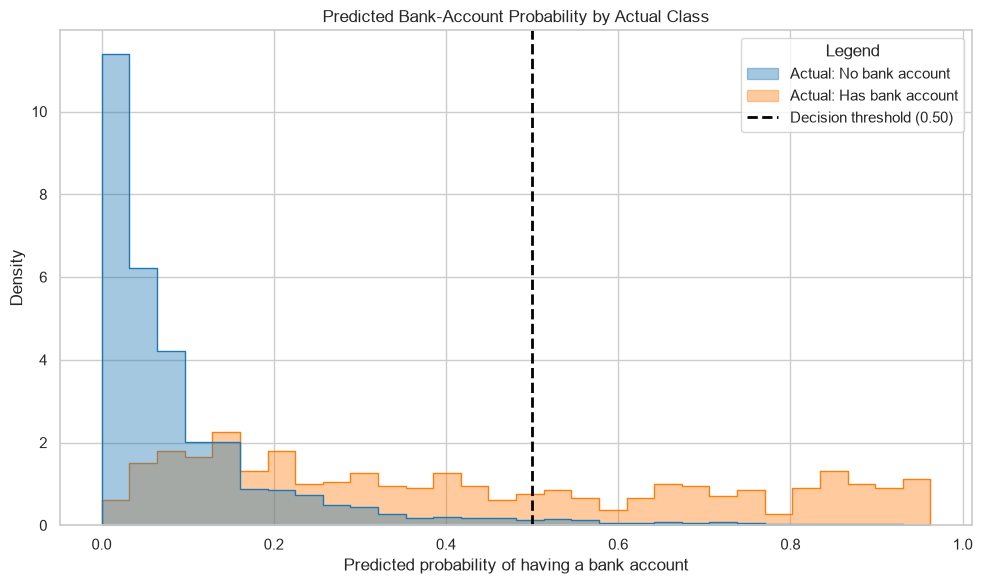

In [144]:
# Visualise predicted probabilities

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.figure(figsize=(10, 6))

palette = {
    "No bank account": "tab:blue",
    "Has bank account": "tab:orange"
}

sns.histplot(
    data=error_analysis,
    x="predicted_probability",
    hue="actual_label",
    hue_order=[
        "No bank account",
        "Has bank account"
    ],
    palette=palette,
    bins=30,
    stat="density",
    common_norm=False,
    element="step",
    alpha=0.40,
    legend=False
)

plt.axvline(
    x=0.50,
    color="black",
    linestyle="--",
    linewidth=2
)

legend_elements = [
    Patch(
        facecolor="tab:blue",
        edgecolor="tab:blue",
        alpha=0.40,
        label="Actual: No bank account"
    ),
    Patch(
        facecolor="tab:orange",
        edgecolor="tab:orange",
        alpha=0.40,
        label="Actual: Has bank account"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=2,
        label="Decision threshold (0.50)"
    )
]

plt.title(
    "Predicted Bank-Account Probability by Actual Class"
)

plt.xlabel(
    "Predicted probability of having a bank account"
)

plt.ylabel("Density")

plt.legend(
    handles=legend_elements,
    title="Legend"
)

plt.tight_layout()
plt.show()

In [145]:
def calculate_group_metrics(data, group_column):
    """
    Calculate classification metrics for each category
    of a selected feature.
    """
    results = []

    for group_name, group_data in data.groupby(
        group_column,
        observed=True
    ):
        actual = group_data["actual"]
        predicted = group_data["predicted"]

        tn, fp, fn, tp = confusion_matrix(
            actual,
            predicted,
            labels=[0, 1]
        ).ravel()

        false_positive_rate = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else np.nan
        )

        false_negative_rate = (
            fn / (fn + tp)
            if (fn + tp) > 0
            else np.nan
        )

        positive_rate = actual.mean()

        results.append(
            {
                group_column: group_name,
                "Respondents": len(group_data),
                "Actual Positive Rate": positive_rate,
                "Accuracy": accuracy_score(
                    actual,
                    predicted
                ),
                "Balanced Accuracy": (
                    balanced_accuracy_score(
                        actual,
                        predicted
                    )
                ),
                "Precision": precision_score(
                    actual,
                    predicted,
                    zero_division=0
                ),
                "Recall": recall_score(
                    actual,
                    predicted,
                    zero_division=0
                ),
                "F1 Score": f1_score(
                    actual,
                    predicted,
                    zero_division=0
                ),
                "False Positive Rate": (
                    false_positive_rate
                ),
                "False Negative Rate": (
                    false_negative_rate
                ),
                "False Positives": fp,
                "False Negatives": fn
            }
        )

    result = pd.DataFrame(results)

    percentage_columns = [
        "Actual Positive Rate",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "False Positive Rate",
        "False Negative Rate"
    ]

    result[percentage_columns] = (
        result[percentage_columns]
        .mul(100)
        .round(1)
    )

    return result

In [146]:
# Analyse errors by country

country_metrics = calculate_group_metrics(
    error_analysis,
    "country"
)

country_metrics.sort_values(
    by="False Negative Rate",
    ascending=False
)

,country,Respondents,Actual Positive Rate,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,False Positive Rate,False Negative Rate,False Positives,False Negatives
1,Rwanda,1746,11.2,90.0,62.1,63.0,26.2,37.0,1.9,73.8,30,144
3,Uganda,473,7.6,93.4,64.6,64.7,30.6,41.5,1.4,69.4,6,25
2,Tanzania,1277,9.2,93.3,71.0,72.9,43.6,54.5,1.6,56.4,19,66
0,Kenya,1209,26.0,80.9,69.4,70.4,45.5,55.3,6.7,54.5,60,171


- In which country is Accuracy lowest?
- In which country is Recall lowest?
- Which country has the highest false-negative rate?
- Are the sample sizes large enough to trust the comparison?

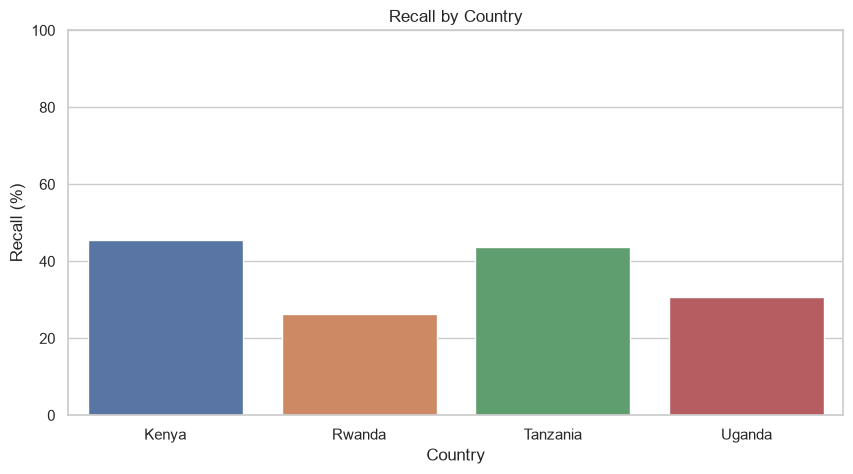

In [147]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=country_metrics,
    x="country",
    y="Recall",
    hue="country",
    legend=False
)

plt.title("Recall by Country")
plt.xlabel("Country")
plt.ylabel("Recall (%)")
plt.ylim(0, 100)
plt.show()

In [148]:
# Analyse errors by location type
location_metrics = calculate_group_metrics(
    error_analysis,
    "location_type"
)

location_metrics

,location_type,Respondents,Actual Positive Rate,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,False Positive Rate,False Negative Rate,False Positives,False Negatives
0,Rural,2896,10.9,90.6,61.7,70.3,24.6,36.4,1.3,75.4,33,239
1,Urban,1809,19.1,86.2,73.0,68.5,51.6,58.8,5.6,48.4,82,167


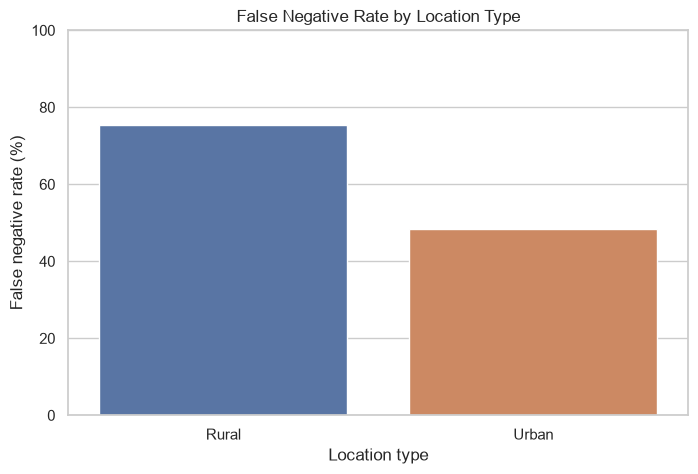

In [149]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=location_metrics,
    x="location_type",
    y="False Negative Rate",
    hue="location_type",
    legend=False
)

plt.title("False Negative Rate by Location Type")
plt.xlabel("Location type")
plt.ylabel("False negative rate (%)")
plt.ylim(0, 100)
plt.show()

# This tells you whether the model misses more account holders in rural or urban areas.

In [150]:
# Analyses errors by gender

gender_metrics = calculate_group_metrics(
    error_analysis,
    "gender_of_respondent"
)

gender_metrics

,gender_of_respondent,Respondents,Actual Positive Rate,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,False Positive Rate,False Negative Rate,False Positives,False Negatives
0,Female,2792,10.9,91.0,65.2,68.5,32.2,43.8,1.8,67.8,45,206
1,Male,1913,18.7,85.9,69.8,69.3,44.1,53.9,4.5,55.9,70,200


In [151]:
# Analyse errors by educational level

education_metrics = calculate_group_metrics(
    error_analysis,
    "education_level"
)

education_metrics.sort_values(
    by="False Negative Rate",
    ascending=False
)

,education_level,Respondents,Actual Positive Rate,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,False Positive Rate,False Negative Rate,False Positives,False Negatives
0,No formal education,897,3.7,96.3,50.0,0.0,0.0,0.0,0.0,100.0,0,33
2,Primary education,2525,8.2,91.7,51.9,42.9,4.4,7.9,0.5,95.6,12,197
3,Secondary education,865,23.4,79.7,64.0,61.4,34.7,44.3,6.6,65.3,44,132
1,Other/Dont know/RTA,14,21.4,64.3,65.2,33.3,66.7,44.4,36.4,33.3,4,1
5,Vocational/Specialised training,159,54.7,70.4,69.6,70.8,78.2,74.3,38.9,21.8,28,19
4,Tertiary education,245,53.5,79.2,79.0,79.9,81.7,80.8,23.7,18.3,27,24


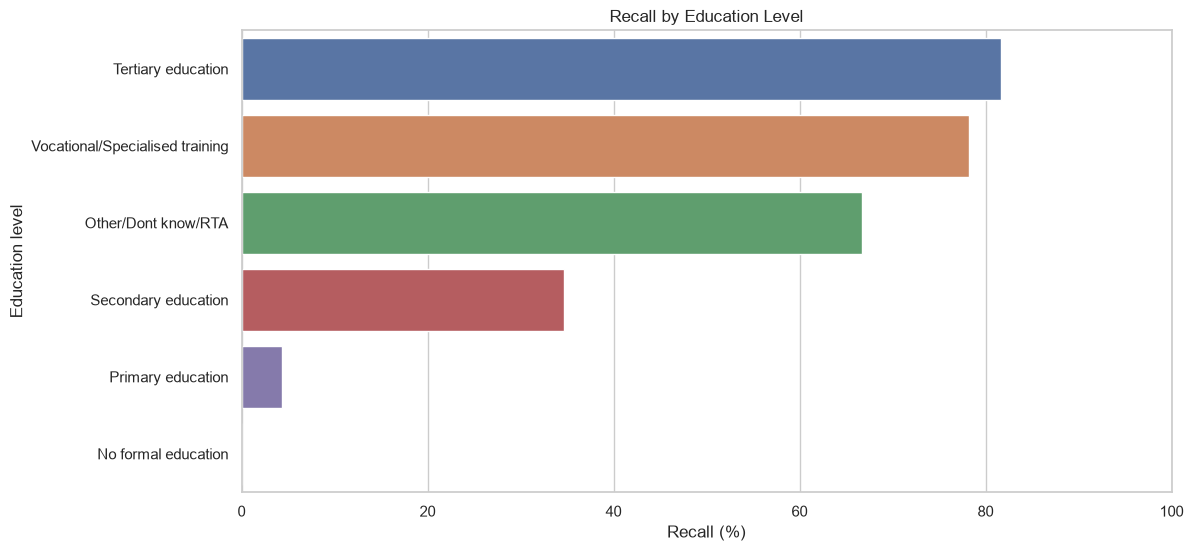

In [152]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=education_metrics.sort_values(
        by="Recall",
        ascending=False
    ),
    x="Recall",
    y="education_level",
    hue="education_level",
    legend=False
)

plt.title("Recall by Education Level")
plt.xlabel("Recall (%)")
plt.ylabel("Education level")
plt.xlim(0, 100)
plt.show()

In [153]:
# Analyse error by employment type

job_metrics = calculate_group_metrics(
    error_analysis,
    "job_type"
)

job_metrics.sort_values(
    by="False Negative Rate",
    ascending=False
)

,job_type,Respondents,Actual Positive Rate,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,False Positive Rate,False Negative Rate,False Positives,False Negatives
0,Dont Know/Refuse to answer,30,10.0,90.0,50.0,0.0,0.0,0.0,0.0,100.0,0,3
6,No Income,125,1.6,98.4,50.0,0.0,0.0,0.0,0.0,100.0,0,2
1,Farming and Fishing,1111,11.3,89.1,54.4,63.2,9.5,16.6,0.7,90.5,7,114
5,Informally employed,1114,7.6,92.5,55.5,55.6,11.8,19.4,0.8,88.2,8,75
8,Remittance Dependent,483,10.8,90.1,56.4,70.0,13.5,22.6,0.7,86.5,3,45
4,Government Dependent,48,29.2,75.0,57.1,100.0,14.3,25.0,0.0,85.7,0,12
9,Self employed,1286,12.6,88.6,66.0,58.0,35.8,44.3,3.7,64.2,42,104
7,Other Income,211,15.6,85.8,65.7,57.1,36.4,44.4,5.1,63.6,9,21
3,Formally employed Private,214,57.0,72.0,71.1,74.6,77.0,75.8,34.8,23.0,32,28
2,Formally employed Government,83,75.9,80.7,63.4,81.3,96.8,88.4,70.0,3.2,14,2


In [154]:
job_metrics_reliable = job_metrics[
    job_metrics["Respondents"] >= 50
].copy()

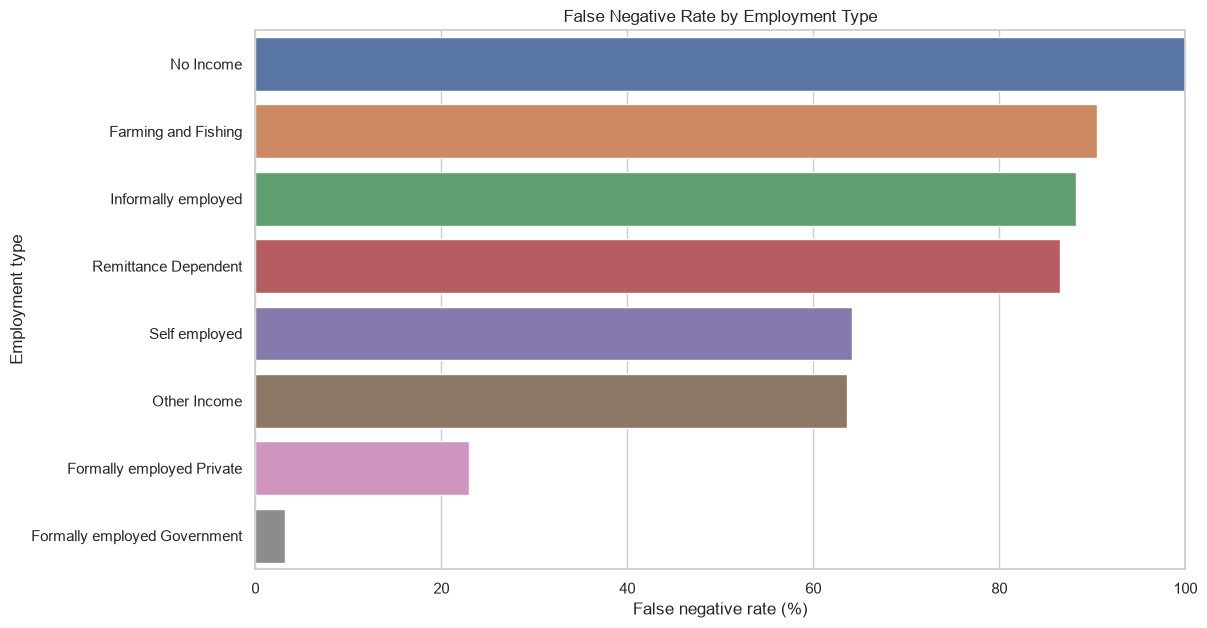

In [155]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=job_metrics_reliable.sort_values(
        by="False Negative Rate",
        ascending=False
    ),
    x="False Negative Rate",
    y="job_type",
    hue="job_type",
    legend=False
)

plt.title("False Negative Rate by Employment Type")
plt.xlabel("False negative rate (%)")
plt.ylabel("Employment type")
plt.xlim(0, 100)
plt.show()

In [156]:
# Analyse error by age group

age_bins = [
    15,
    25,
    35,
    45,
    55,
    65,
    float("inf")
]

age_labels = [
    "16–25",
    "26–35",
    "36–45",
    "46–55",
    "56–65",
    "66+"
]

error_analysis["age_group"] = pd.cut(
    error_analysis["age_of_respondent"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

In [157]:
age_metrics = calculate_group_metrics(
    error_analysis,
    "age_group"
)

age_metrics

,age_group,Respondents,Actual Positive Rate,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,False Positive Rate,False Negative Rate,False Positives,False Negatives
0,16–25,1098,8.7,92.3,63.4,61.4,28.4,38.8,1.7,71.6,17,68
1,26–35,1340,16.5,87.8,70.3,70.5,44.3,54.4,3.7,55.7,41,123
2,36–45,888,17.9,87.0,69.7,73.9,42.8,54.2,3.3,57.2,24,91
3,46–55,569,13.4,90.3,71.6,71.4,46.1,56.0,2.8,53.9,14,41
4,56–65,410,15.9,86.8,64.7,67.7,32.3,43.8,2.9,67.7,10,44
5,66+,400,11.5,88.0,56.3,43.8,15.2,22.6,2.5,84.8,9,39


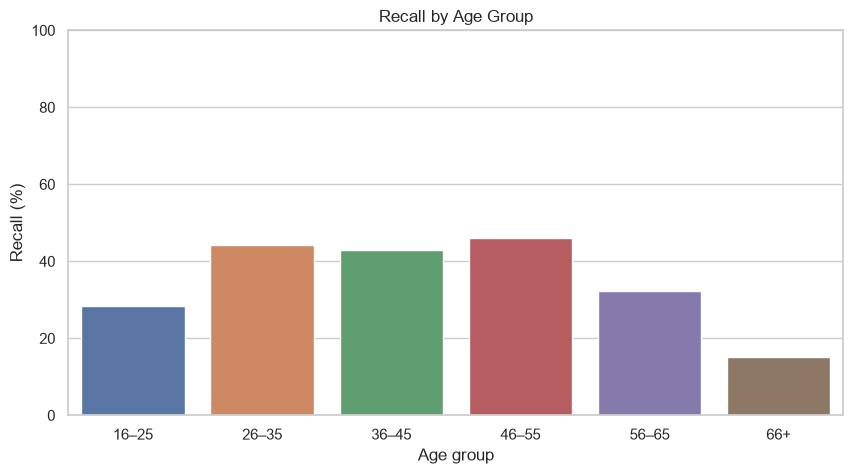

In [158]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=age_metrics,
    x="age_group",
    y="Recall",
    hue="age_group",
    legend=False
)

plt.title("Recall by Age Group")
plt.xlabel("Age group")
plt.ylabel("Recall (%)")
plt.ylim(0, 100)
plt.show()

In [159]:
# Compact error-analysis summary

group_summary = pd.DataFrame(
    {
        "Dimension": [
            "Country",
            "Location type",
            "Gender",
            "Education level",
            "Employment type",
            "Age group"
        ],
        "Group with highest false-negative rate": [
            country_metrics.loc[
                country_metrics[
                    "False Negative Rate"
                ].idxmax(),
                "country"
            ],
            location_metrics.loc[
                location_metrics[
                    "False Negative Rate"
                ].idxmax(),
                "location_type"
            ],
            gender_metrics.loc[
                gender_metrics[
                    "False Negative Rate"
                ].idxmax(),
                "gender_of_respondent"
            ],
            education_metrics.loc[
                education_metrics[
                    "False Negative Rate"
                ].idxmax(),
                "education_level"
            ],
            job_metrics_reliable.loc[
                job_metrics_reliable[
                    "False Negative Rate"
                ].idxmax(),
                "job_type"
            ],
            age_metrics.loc[
                age_metrics[
                    "False Negative Rate"
                ].idxmax(),
                "age_group"
            ]
        ]
    }
)

group_summary

,Dimension,Group with highest false-negative rate
0,Country,Rwanda
1,Location type,Rural
2,Gender,Female
3,Education level,No formal education
4,Employment type,No Income
5,Age group,66+


## Error Analysis

Error analysis was performed on the held-out validation set to understand where the tuned Gradient Boosting model makes mistakes. Predictions were separated into true negatives, false positives, false negatives, and true positives.

Particular attention was given to false negatives because these represent actual bank-account holders whom the model failed to identify. Model performance was examined across country, location type, gender, education level, employment type, and age group.

The analysis also considered prediction confidence. High-confidence errors are especially important because they represent cases in which the model was incorrect despite assigning a strong probability to its prediction.

Differences between demographic groups are descriptive and do not by themselves prove bias or causation. Group size, class prevalence, survey design, and omitted variables must also be considered when interpreting the results.

---

### Model interpretation and feature importance

Model evaluation tells us:

How well does the model predict bank-account ownership?

Model interpretation tells us:

Which information does the model use most when making those predictions?

For stakeholders, a result such as “Accuracy = 88.8%” is not enough. Banks, governments, and development organisations also want to understand which respondent characteristics are associated with the predictions.
Possible important features might include:

- Country
- Education level
- Employment type
- Mobile-phone access
- Urban or rural location
- Age

In [160]:
best_gradient_boosting_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['country','year','location_type',...,'marital_status','education_level', 'job_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [161]:
print(
    best_gradient_boosting_model.named_steps.keys()
)

dict_keys(['preprocessor', 'model'])


In [162]:
fitted_preprocessor = (
    best_gradient_boosting_model
    .named_steps["preprocessor"]
)

fitted_gradient_boosting = (
    best_gradient_boosting_model
    .named_steps["model"]
)

# The first object contains the fitted preprocessing rules. The second contains the fitted Gradient Boosting algorithm.

Permutation importance

Permutation importance answers this question:

- How much does model performance decrease if we randomly mix the values of one feature?



In [163]:
# Import the function
from sklearn.inspection import permutation_importance

In [164]:
# Calculate permutation importance

permutation_results = permutation_importance(
    estimator=best_gradient_boosting_model,
    X=X_valid,
    y=y_valid,
    scoring="accuracy",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

In [165]:
# Create the importance table

permutation_importance_table = pd.DataFrame(
    {
        "Feature": X_valid.columns,
        "Importance Mean": (
            permutation_results.importances_mean
        ),
        "Importance Standard Deviation": (
            permutation_results.importances_std
        )
    }
).sort_values(
    by="Importance Mean",
    ascending=False
).reset_index(drop=True)

permutation_importance_table.round(4)

,Feature,Importance Mean,Importance Standard Deviation
0,education_level,0.0358,0.0026
1,job_type,0.0182,0.0017
2,country,0.0066,0.0015
3,cellphone_access,0.0045,0.0013
4,location_type,0.0030,0.0015
5,age_of_respondent,0.0029,0.0017
6,year,0.0022,0.0015
7,relationship_with_head,0.0021,0.0012
8,gender_of_respondent,0.0012,0.0012
9,marital_status,0.0011,0.0011


/var/folders/xd/z5xpb5h532dfrdy6xz3v34t40000gn/T/ipykernel_83522/540516347.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:steelblue'` for the same effect.

  sns.barplot(


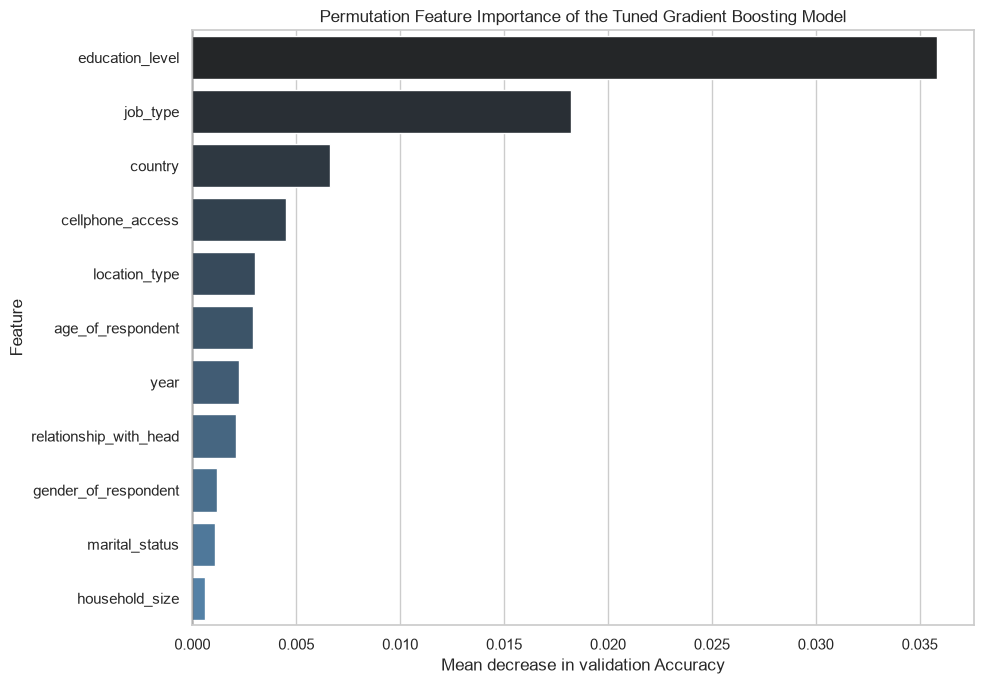

In [166]:
# Visualise permutation importance

plt.figure(figsize=(10, 7))

sns.barplot(
    data=permutation_importance_table,
    x="Importance Mean",
    y="Feature",
    hue="Feature",
    legend=False,
    color="steelblue"
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.title(
    "Permutation Feature Importance "
    "of the Tuned Gradient Boosting Model"
)

plt.xlabel(
    "Mean decrease in validation Accuracy"
)

plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [167]:
# Accuracy focuses heavily pn the majority class. We should therefore repeat the analysis using F1 score

# Calculating permutation importance using F1 score

permutation_results_f1 = permutation_importance(
    estimator=best_gradient_boosting_model,
    X=X_valid,
    y=y_valid,
    scoring="f1",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

In [168]:
permutation_importance_f1_table = pd.DataFrame(
    {
        "Feature": X_valid.columns,
        "F1 Importance Mean": (
            permutation_results_f1.importances_mean
        ),
        "F1 Importance Standard Deviation": (
            permutation_results_f1.importances_std
        )
    }
).sort_values(
    by="F1 Importance Mean",
    ascending=False
).reset_index(drop=True)

permutation_importance_f1_table.round(4)

,Feature,F1 Importance Mean,F1 Importance Standard Deviation
0,education_level,0.2158,0.0106
1,job_type,0.1143,0.0088
2,cellphone_access,0.0575,0.0072
3,country,0.0491,0.0090
4,location_type,0.0204,0.0091
5,relationship_with_head,0.0191,0.0067
6,gender_of_respondent,0.0164,0.0054
7,marital_status,0.0143,0.0051
8,age_of_respondent,0.0133,0.0098
9,year,0.0094,0.0058


Which variables are most important for correctly identifying the minority class while balancing Precision and Recall?

In [169]:
# Compare Accuracy-based and F1-based importance

importance_comparison = (
    permutation_importance_table[
        ["Feature", "Importance Mean"]
    ]
    .merge(
        permutation_importance_f1_table[
            ["Feature", "F1 Importance Mean"]
        ],
        on="Feature"
    )
    .sort_values(
        by="Importance Mean",
        ascending=False
    )
)

importance_comparison.round(4)

,Feature,Importance Mean,F1 Importance Mean
0,education_level,0.0358,0.2158
1,job_type,0.0182,0.1143
2,country,0.0066,0.0491
3,cellphone_access,0.0045,0.0575
4,location_type,0.0030,0.0204
5,age_of_respondent,0.0029,0.0133
6,year,0.0022,0.0094
7,relationship_with_head,0.0021,0.0191
8,gender_of_respondent,0.0012,0.0164
9,marital_status,0.0011,0.0143


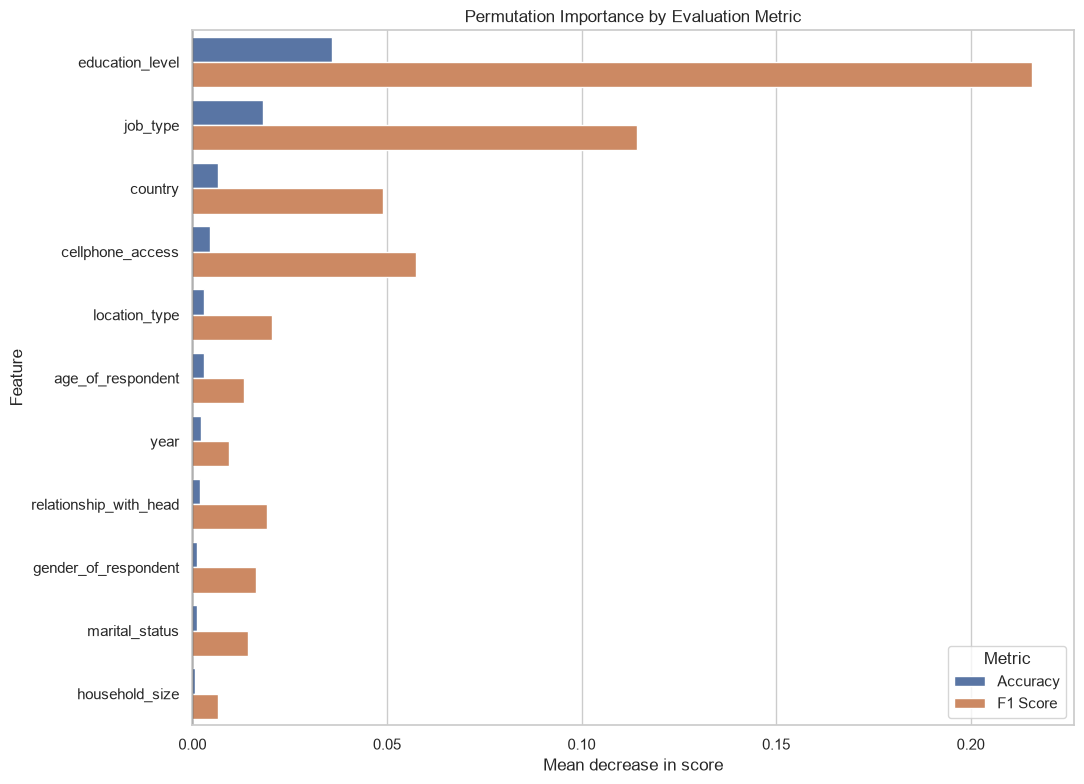

In [170]:
# Visualise 

importance_comparison_long = (
    importance_comparison.melt(
        id_vars="Feature",
        value_vars=[
            "Importance Mean",
            "F1 Importance Mean"
        ],
        var_name="Metric",
        value_name="Importance"
    )
)

importance_comparison_long["Metric"] = (
    importance_comparison_long["Metric"].replace(
        {
            "Importance Mean": "Accuracy",
            "F1 Importance Mean": "F1 Score"
        }
    )
)

plt.figure(figsize=(11, 8))

sns.barplot(
    data=importance_comparison_long,
    x="Importance",
    y="Feature",
    hue="Metric"
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.title(
    "Permutation Importance by Evaluation Metric"
)

plt.xlabel("Mean decrease in score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Supporting analysis: Built-in Gradient Boosting importance

This method measures how much the individual decision trees use each transformed feature to reduce classification error.

It is faster than permutation importance but has limitations:

- It may favour variables with many possible splits.
- One categorical variable becomes several One-Hot-Encoded features.
- It describes how the model was constructed, not necessarily how much each feature improves unseen-data performance.



In [171]:
# Obtain the transformed feature names

transformed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

print(
    "Number of transformed features:",
    len(transformed_feature_names)
)

print(
    transformed_feature_names[:20]
)

Number of transformed features: 40
['numerical__year' 'numerical__household_size'
 'numerical__age_of_respondent' 'categorical__country_Kenya'
 'categorical__country_Rwanda' 'categorical__country_Tanzania'
 'categorical__country_Uganda' 'categorical__location_type_Rural'
 'categorical__location_type_Urban' 'categorical__cellphone_access_No'
 'categorical__cellphone_access_Yes'
 'categorical__gender_of_respondent_Female'
 'categorical__gender_of_respondent_Male'
 'categorical__relationship_with_head_Child'
 'categorical__relationship_with_head_Head of Household'
 'categorical__relationship_with_head_Other non-relatives'
 'categorical__relationship_with_head_Other relative'
 'categorical__relationship_with_head_Parent'
 'categorical__relationship_with_head_Spouse'
 'categorical__marital_status_Divorced/Seperated']


In [172]:
built_in_importances = (
    fitted_gradient_boosting.feature_importances_
)

In [173]:
assert len(transformed_feature_names) == len(
    built_in_importances
)

print(
    "Feature names and importance values match."
)

Feature names and importance values match.


In [174]:
built_in_importance_table = pd.DataFrame(
    {
        "Transformed Feature": (
            transformed_feature_names
        ),
        "Importance": built_in_importances
    }
).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

built_in_importance_table.head(20).round(4)

,Transformed Feature,Importance
0,categorical__education_level_Tertiary education,0.1140
1,categorical__job_type_Formally employed Private,0.1116
2,categorical__job_type_Formally employed Govern...,0.1016
3,categorical__education_level_Vocational/Specia...,0.0650
4,categorical__country_Kenya,0.0525
5,categorical__cellphone_access_Yes,0.0508
6,categorical__education_level_Primary education,0.0501
7,numerical__age_of_respondent,0.0495
8,categorical__education_level_No formal education,0.0481
9,numerical__year,0.0379


In [175]:
built_in_importance_table[
    "Readable Feature"
] = (
    built_in_importance_table[
        "Transformed Feature"
    ]
    .str.replace(
        "numerical__",
        "",
        regex=False
    )
    .str.replace(
        "categorical__",
        "",
        regex=False
    )
)

In [176]:
built_in_importance_table[
    [
        "Readable Feature",
        "Importance"
    ]
].head(20).round(4)

,Readable Feature,Importance
0,education_level_Tertiary education,0.1140
1,job_type_Formally employed Private,0.1116
2,job_type_Formally employed Government,0.1016
3,education_level_Vocational/Specialised training,0.0650
4,country_Kenya,0.0525
5,cellphone_access_Yes,0.0508
6,education_level_Primary education,0.0501
7,age_of_respondent,0.0495
8,education_level_No formal education,0.0481
9,year,0.0379


/var/folders/xd/z5xpb5h532dfrdy6xz3v34t40000gn/T/ipykernel_83522/2111315116.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:darkorange'` for the same effect.

  sns.barplot(


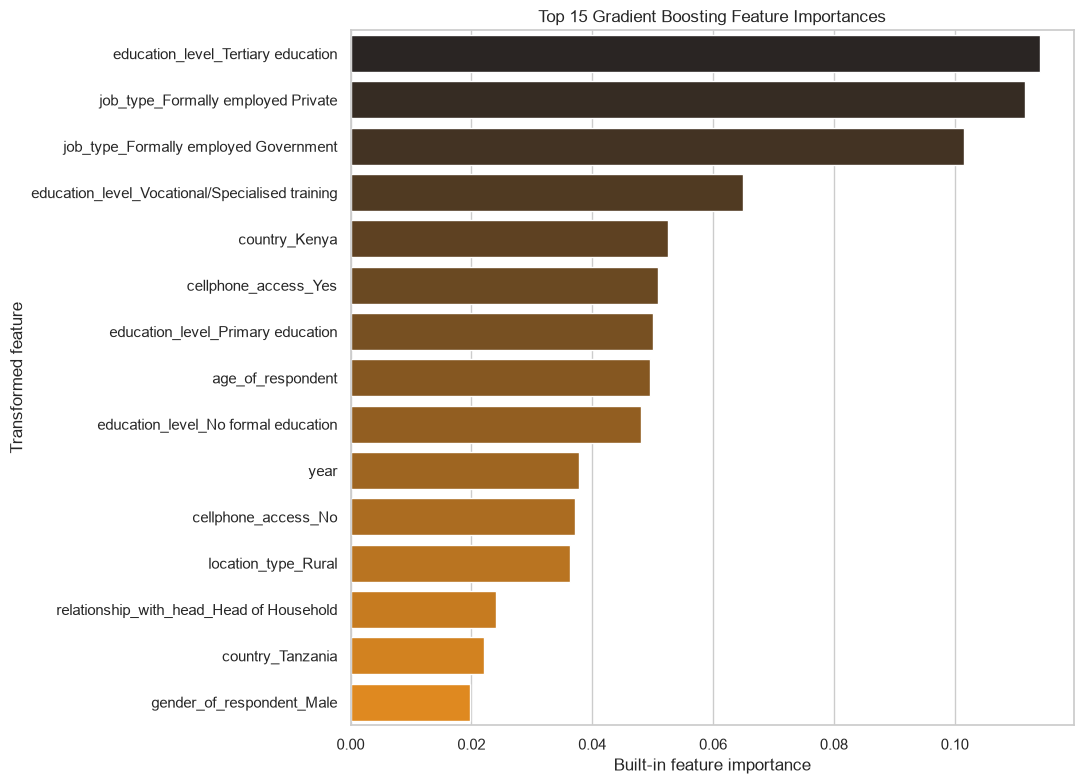

In [177]:
# 15 most important transformed features

top_transformed_features = (
    built_in_importance_table.head(15)
)

plt.figure(figsize=(11, 8))

sns.barplot(
    data=top_transformed_features,
    x="Importance",
    y="Readable Feature",
    hue="Readable Feature",
    legend=False,
    color="darkorange"
)

plt.title(
    "Top 15 Gradient Boosting "
    "Feature Importances"
)

plt.xlabel("Built-in feature importance")
plt.ylabel("Transformed feature")
plt.tight_layout()
plt.show()

# Reveal which specific categories the model uses frequently,

In [178]:
def get_original_feature_name(
    transformed_name,
    original_features
):
    """
    Match a transformed feature name to its original
    feature name.
    """
    cleaned_name = (
        transformed_name
        .replace("numerical__", "")
        .replace("categorical__", "")
    )

    matching_features = [
        feature
        for feature in original_features
        if (
            cleaned_name == feature
            or cleaned_name.startswith(
                feature + "_"
            )
        )
    ]

    if matching_features:
        return max(
            matching_features,
            key=len
        )

    return cleaned_name

In [179]:
original_features = (
    numerical_features
    + categorical_features
)

In [180]:
built_in_importance_table[
    "Original Feature"
] = (
    built_in_importance_table[
        "Transformed Feature"
    ].apply(
        lambda name: get_original_feature_name(
            name,
            original_features
        )
    )
)

In [181]:
aggregated_importance_table = (
    built_in_importance_table
    .groupby(
        "Original Feature",
        as_index=False
    )["Importance"]
    .sum()
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

aggregated_importance_table.round(4)

,Original Feature,Importance
0,education_level,0.2966
1,job_type,0.2632
2,country,0.0918
3,cellphone_access,0.0880
4,age_of_respondent,0.0495
5,location_type,0.0440
6,relationship_with_head,0.0389
7,year,0.0379
8,gender_of_respondent,0.0379
9,marital_status,0.0331


In [182]:
print(
    "Total importance:",
    aggregated_importance_table[
        "Importance"
    ].sum()
)

Total importance: 0.9999999999999999


/var/folders/xd/z5xpb5h532dfrdy6xz3v34t40000gn/T/ipykernel_83522/2857374347.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:darkorange'` for the same effect.

  sns.barplot(


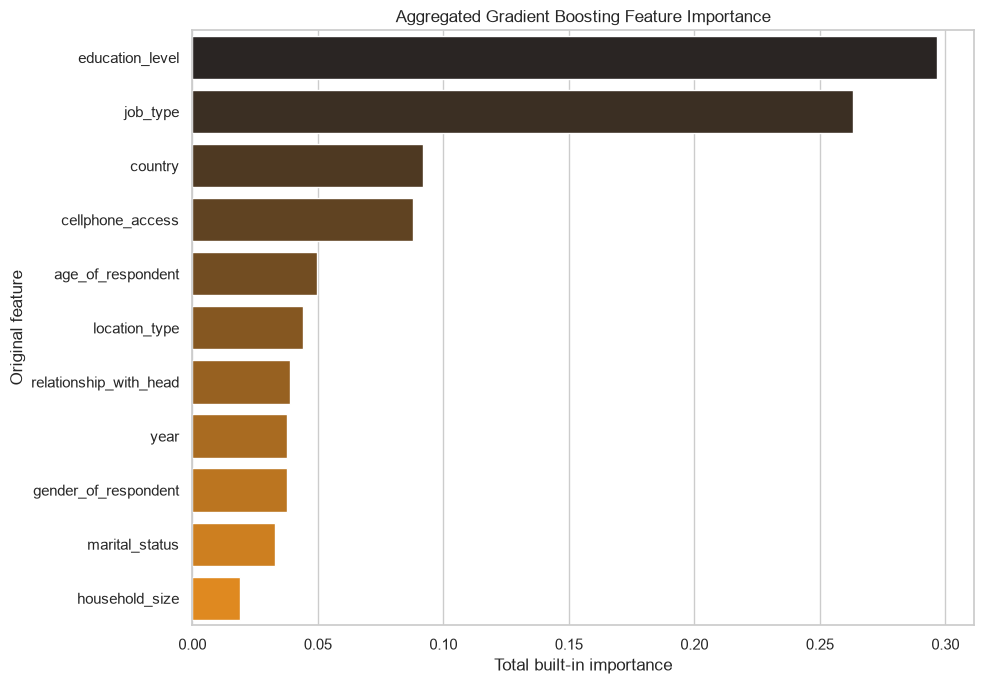

In [183]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=aggregated_importance_table,
    x="Importance",
    y="Original Feature",
    hue="Original Feature",
    legend=False,
    color="darkorange"
)

plt.title(
    "Aggregated Gradient Boosting "
    "Feature Importance"
)

plt.xlabel("Total built-in importance")
plt.ylabel("Original feature")
plt.tight_layout()
plt.show()

In [184]:
combined_importance = (
    permutation_importance_table[
        ["Feature", "Importance Mean"]
    ]
    .merge(
        aggregated_importance_table,
        left_on="Feature",
        right_on="Original Feature",
        how="left"
    )
    .drop(
        columns="Original Feature"
    )
    .rename(
        columns={
            "Importance Mean": (
                "Permutation Importance"
            ),
            "Importance": (
                "Built-in Importance"
            )
        }
    )
    .sort_values(
        by="Permutation Importance",
        ascending=False
    )
)

combined_importance.round(4)

,Feature,Permutation Importance,Built-in Importance
0,education_level,0.0358,0.2966
1,job_type,0.0182,0.2632
2,country,0.0066,0.0918
3,cellphone_access,0.0045,0.0880
4,location_type,0.0030,0.0440
5,age_of_respondent,0.0029,0.0495
6,year,0.0022,0.0379
7,relationship_with_head,0.0021,0.0389
8,gender_of_respondent,0.0012,0.0379
9,marital_status,0.0011,0.0331


The rankings differ because the methods answer different questions:

- Permutation importance: How much does validation performance depend on the feature?
- Built-in importance: How strongly was the feature used in the trained trees?

In [185]:
stakeholder_importance = (
    permutation_importance_table
    .head(5)
    .copy()
)

stakeholder_importance[
    "Importance in percentage points"
] = (
    stakeholder_importance[
        "Importance Mean"
    ]
    .mul(100)
    .round(2)
)

stakeholder_importance[
    [
        "Feature",
        "Importance in percentage points"
    ]
]

,Feature,Importance in percentage points
0,education_level,3.58
1,job_type,1.82
2,country,0.66
3,cellphone_access,0.45
4,location_type,0.30


Interpretation:

Shuffling this feature reduced validation Accuracy by approximately X percentage points. For example:
Shuffling teh feature "education_level reduced validation Accuracy by approximately 3.58 % points.

## Model Interpretation

Permutation importance was used as the primary model-interpretation method. This method measures how much validation performance decreases when the values of one feature are randomly shuffled.

The most important predictors were **[Feature 1]**, **[Feature 2]**, **[Feature 3]**, **[Feature 4]**, and **[Feature 5]**. Shuffling these variables produced the largest decrease in validation Accuracy, indicating that the model relies strongly on them when predicting bank-account ownership.

The built-in Gradient Boosting feature importance produced a broadly **[similar/different]** ranking. The descriptive analysis also showed differences in observed bank-account ownership across important categories. For example, **[insert one or two findings from the account-rate tables]**.

These results describe predictive associations rather than causal effects. A feature can be important because it represents broader economic, geographic, or social conditions. The analysis therefore cannot establish that changing a single feature would directly cause a person to obtain a bank account.

---

### Train the Final Model and predict Test.csv

At this point, all model-development decisions have been made:

- Gradient Boosting was selected.
- Its hyperparameters were tuned.
- It was evaluated using cross-validation.
- It was evaluated on the held-out validation set.
- Its errors and important features were analysed.
- We can now use all available labelled observations from Train.csv to fit the final model.

Entire Train.csv

        │
        ▼
Final tuned Gradient Boosting pipeline

        │
        ▼
Predictions for Test.csv



In [186]:
# Confirm the required objects

X #All modelling features from Train.csv
y #All known target values
X_test # Features from Test.csv
best_gradient_boosting_model # Best tuned pipeline
test # Original test data, including identifiers 

,country,year,uniqueid,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_6056,Urban,Yes,3,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government
1,Kenya,2018,uniqueid_6060,Urban,Yes,7,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private
2,Kenya,2018,uniqueid_6065,Rural,No,3,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent
3,Kenya,2018,uniqueid_6072,Rural,No,6,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent
4,Kenya,2018,uniqueid_6073,Urban,No,3,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent
...,...,...,...,...,...,...,...,...,...,...,...,...
10081,Uganda,2018,uniqueid_2998,Rural,No,2,62,Female,Spouse,Married/Living together,Primary education,Self employed
10082,Uganda,2018,uniqueid_2999,Urban,Yes,8,42,Male,Head of Household,Married/Living together,Primary education,Self employed
10083,Uganda,2018,uniqueid_3000,Urban,Yes,1,39,Male,Head of Household,Single/Never Married,Secondary education,Other Income
10084,Uganda,2018,uniqueid_3001,Rural,Yes,6,28,Female,Spouse,Married/Living together,Primary education,Self employed


In [187]:
print("Full training features:", X.shape)
print("Full training target:", y.shape)
print("Competition test features:", X_test.shape)
print("Original test data:", test.shape)

Full training features: (23524, 11)
Full training target: (23524,)
Competition test features: (10086, 11)
Original test data: (10086, 12)


In [188]:
#Verifying the target encoding

print("Target values:", sorted(y.unique()))
print("\nTarget distribution:")
print(y.value_counts())

Target values: [np.int64(0), np.int64(1)]

Target distribution:
bank_account
0    20212
1     3312
Name: count, dtype: int64


In [189]:
assert y.notna().all(), (
    "The target contains missing or unexpected values."
)

y = y.astype(int)

In [190]:
# Verifying the feature columns
# The final training features and test features must contain the same columns in the same order.

print("Training columns:")
print(X.columns.tolist())

print("\nTest columns:")
print(X_test.columns.tolist())

Training columns:
['country', 'year', 'location_type', 'cellphone_access', 'household_size', 'age_of_respondent', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']

Test columns:
['country', 'year', 'location_type', 'cellphone_access', 'household_size', 'age_of_respondent', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']


In [191]:
assert set(X.columns) == set(X_test.columns), (
    "Training and test data do not contain "
    "the same feature columns."
)

In [192]:
X_test = X_test[X.columns]

In [193]:
assert list(X.columns) == list(X_test.columns), (
    "Training and test columns are not in the same order."
)

print(
    "Training and test features have matching columns."
)

# The final model expects the same type of input it received during training


Training and test features have matching columns.


In [194]:
# Checking for missing values

print("Missing values in full training features:")
print(X.isna().sum().sort_values(ascending=False))

print("Missing values in competition test features:")
print(X_test.isna().sum().sort_values(ascending=False))

Missing values in full training features:
country                   0
year                      0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64
Missing values in competition test features:
country                   0
year                      0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64


 Creating an independent final-model copy

Current best_gradient_boosting_model was fitted on X_train and y_train. We want a fresh copy that will be fitted on all of X and y.

USing Clone:

- It copies the pipeline structure.
- It copies the selected hyperparameters.
- It does not copy the previously learned preprocessing values or trees.
- It prevents accidental modification of the model used for validation.


In [195]:
from sklearn.base import clone

In [196]:
final_model = clone(
    best_gradient_boosting_model
)

In [197]:
final_model.get_params()["model"]

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.15
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",150
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",20
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_features max_features: {'sqrt', 'log2'}, int or float, default=NoneThe number of features to consider when looking for the best split:- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0]` and the features considered at each split will be `max(1, int(max_features * n_features_in_))`.- If 'sqrt', then `max_features=sqrt(n_features)`.- If 'log2', then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Choosing `max_features < n_features` leads to a reduction of varianceand an increase in bias.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[

In [198]:
print("Final Gradient Boosting parameters:")

for parameter, value in (
    gradient_boosting_search.best_params_.items()
):
    print(f"{parameter}: {value}")

Final Gradient Boosting parameters:
model__subsample: 1.0
model__n_estimators: 150
model__min_samples_split: 20
model__min_samples_leaf: 1
model__max_features: log2
model__max_depth: 4
model__learning_rate: 0.15


In [199]:
# Train the final model on all labelled data

final_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['country','year','location_type',...,'marital_status','education_level', 'job_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [200]:
print(
    "Final model successfully trained "
    f"on {len(X):,} labelled observations."
)

Final model successfully trained on 23,524 labelled observations.


In [201]:
# Generate final class predictions for Test.csv

test_predictions = final_model.predict(X_test)

In [202]:
print("Number of test predictions:", len(test_predictions))
print("First ten predictions:", test_predictions[:10])
print("Unique predicted classes:", np.unique(test_predictions))

Number of test predictions: 10086
First ten predictions: [1 1 0 0 0 0 0 0 0 0]
Unique predicted classes: [0 1]


In [203]:
#Verifying that every test row received exactly one prediction:

assert len(test_predictions) == len(test), (
    "The number of predictions does not match "
    "the number of test observations."
)

print("Every test observation has one prediction.")

Every test observation has one prediction.


In [204]:
# Generating predicted probabilities

test_probabilities = final_model.predict_proba(
    X_test
)[:, 1]


In [205]:
print(
    "Minimum predicted probability:",
    round(test_probabilities.min(), 4)
)

print(
    "Maximum predicted probability:",
    round(test_probabilities.max(), 4)
)

print(
    "Mean predicted probability:",
    round(test_probabilities.mean(), 4)
)

Minimum predicted probability: 0.0008
Maximum predicted probability: 0.9883
Mean predicted probability: 0.1411


In [206]:
assert np.all(
    (test_probabilities >= 0)
    & (test_probabilities <= 1)
), "Predicted probabilities must be between 0 and 1."

print("All probabilities are valid.")

All probabilities are valid.


In [207]:
# Inspect the prediction distribution

test_prediction_distribution = (
    pd.Series(
        test_predictions,
        name="bank_account"
    )
    .value_counts()
    .sort_index()
    .rename(
        index={
            0: "No bank account",
            1: "Has bank account"
        }
    )
)

test_prediction_distribution

bank_account
No bank account     9319
Has bank account     767
Name: count, dtype: int64

In [208]:
test_prediction_percentages = (
    pd.Series(
        test_predictions,
        name="bank_account"
    )
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .rename(
        index={
            0: "No bank account",
            1: "Has bank account"
        }
    )
)

test_prediction_percentages

bank_account
No bank account     92.4
Has bank account     7.6
Name: proportion, dtype: float64

In [209]:
test_prediction_summary = pd.DataFrame(
    {
        "Count": test_prediction_distribution,
        "Percentage": test_prediction_percentages
    }
)

test_prediction_summary

,Count,Percentage
bank_account,,
No bank account,9319,92.4
Has bank account,767,7.6


In [210]:
# Comparing it with the training target distributing

training_positive_rate = y.mean() * 100
test_predicted_positive_rate = test_predictions.mean() * 100

print(
    "Actual positive rate in Train.csv:",
    round(training_positive_rate, 2),
    "%"
)

print(
    "Predicted positive rate in Test.csv:",
    round(test_predicted_positive_rate, 2),
    "%"
)

Actual positive rate in Train.csv: 14.08 %
Predicted positive rate in Test.csv: 7.6 %


In [211]:
#Creating the competition identifier

submission_ids = (
    test["uniqueid"].astype(str)
    + " x "
    + test["country"].astype(str)
)

In [212]:
submission_ids.head()

0    uniqueid_6056 x Kenya
1    uniqueid_6060 x Kenya
2    uniqueid_6065 x Kenya
3    uniqueid_6072 x Kenya
4    uniqueid_6073 x Kenya
dtype: str

In [213]:
print(
    "Number of submission IDs:",
    len(submission_ids)
)

print(
    "Number of unique submission IDs:",
    submission_ids.nunique()
)

Number of submission IDs: 10086
Number of unique submission IDs: 10086


In [214]:
assert submission_ids.is_unique, (
    "Submission identifiers are not unique."
)

In [215]:
sample_submission = pd.read_csv(
    data_path + "SampleSubmission.csv"
)

print("Sample submission shape:")
print(sample_submission.shape)

print("\nSample submission columns:")
print(sample_submission.columns.tolist())

display(sample_submission.head())

Sample submission shape:
(33610, 2)

Sample submission columns:
['unique_id', 'bank_account']


,unique_id,bank_account
0,uniqueid_1 x Kenya,0
1,uniqueid_2 x Kenya,0
2,uniqueid_3 x Kenya,0
3,uniqueid_4 x Kenya,0
4,uniqueid_5 x Kenya,0


In [216]:
print(
    "Rows in Test.csv:",
    len(test)
)

print(
    "Rows in SampleSubmission.csv:",
    len(sample_submission)
)

Rows in Test.csv: 10086
Rows in SampleSubmission.csv: 33610


In [217]:
submission = pd.DataFrame(
    {
        "unique_id": submission_ids,
        "bank_account": test_predictions.astype(int)
    }
)

In [218]:
display(submission.head(10))

,unique_id,bank_account
0,uniqueid_6056 x Kenya,1
1,uniqueid_6060 x Kenya,1
2,uniqueid_6065 x Kenya,0
3,uniqueid_6072 x Kenya,0
4,uniqueid_6073 x Kenya,0
5,uniqueid_6074 x Kenya,0
6,uniqueid_6075 x Kenya,0
7,uniqueid_6076 x Kenya,0
8,uniqueid_6077 x Kenya,0
9,uniqueid_6078 x Kenya,0


In [219]:
print("Submission shape:", submission.shape)

Submission shape: (10086, 2)


Validating the submission 

In [220]:
expected_columns = [
    "unique_id",
    "bank_account"
]

assert submission.columns.tolist() == expected_columns, (
    "Submission columns are incorrect."
)

In [221]:
# Checking missing values

assert len(submission) == len(test), (
    "Submission must contain one row "
    "for every Test.csv observation."
)

In [222]:
#Checking identifiers 

assert not submission.isna().any().any(), (
    "Submission contains missing values."
)

In [223]:
# Check target values

assert set(
    submission["bank_account"].unique()
).issubset({0, 1}), (
    "Predictions must contain only 0 and 1."
)

In [224]:
# Confirming identifier order

assert submission["unique_id"].equals(
    submission_ids.reset_index(drop=True)
), (
    "Submission IDs are not in the same order "
    "as the test observations."
)

In [225]:
print("Submission validation passed.")
print("Rows:", len(submission))
print("Columns:", submission.columns.tolist())
print(
    "Missing values:",
    submission.isna().sum().sum()
)
print(
    "Predicted classes:",
    sorted(
        submission["bank_account"].unique()
    )
)

Submission validation passed.
Rows: 10086
Columns: ['unique_id', 'bank_account']
Missing values: 0
Predicted classes: [np.int64(0), np.int64(1)]


In [226]:
# Save the competition submission

submission.to_csv(
    "final_submission.csv",
    index=False # Is important. Otherwise, Pandas adds an unwanted extra index column
)

In [227]:
submission_check = pd.read_csv(
    "final_submission.csv"
)

display(submission_check.head())

print(
    "Saved submission shape:",
    submission_check.shape
)

,unique_id,bank_account
0,uniqueid_6056 x Kenya,1
1,uniqueid_6060 x Kenya,1
2,uniqueid_6065 x Kenya,0
3,uniqueid_6072 x Kenya,0
4,uniqueid_6073 x Kenya,0


Saved submission shape: (10086, 2)


In [228]:
assert submission_check.equals(submission), (
    "The saved file differs from the "
    "original submission DataFrame."
)

print(
    "final_submission.csv was saved successfully."
)

final_submission.csv was saved successfully.


Saving the final model

In [229]:
import joblib

In [230]:
joblib.dump(
    final_model,
    "final_gradient_boosting_pipeline.joblib"
)

['final_gradient_boosting_pipeline.joblib']

In [231]:
loaded_final_model = joblib.load(
    "final_gradient_boosting_pipeline.joblib"
)

In [232]:
original_sample_predictions = final_model.predict(
    X_test.head(5)
)

loaded_sample_predictions = loaded_final_model.predict(
    X_test.head(5)
)

assert np.array_equal(
    original_sample_predictions,
    loaded_sample_predictions
)

print(
    "The saved model was loaded and "
    "reproduced the same predictions."
)

The saved model was loaded and reproduced the same predictions.


## Final Model Training and Test Predictions

After model selection, hyperparameter tuning, validation, error analysis, and interpretation were completed, the final Gradient Boosting pipeline was retrained using all labelled observations from `Train.csv`.

This final training step combined the previous internal training and validation subsets. Using all available labelled data gives the deployment model the largest possible training sample. The previously reported cross-validation and held-out validation results remain the estimates of unseen-data performance; training performance from the final model was not used as an evaluation result.

The fitted pipeline was then applied to `Test.csv`, which contains no target labels. One binary prediction was generated for every test respondent, where `0` represents no bank account and `1` represents ownership or use of a bank account.

The predictions were combined with the required respondent identifiers and saved as `final_submission.csv`. The submission was checked for the correct column names, row count, identifier order, missing values, duplicate identifiers, and valid target values.

---

## Executive Summary

This project developed a machine-learning model to predict whether an individual in Kenya, Rwanda, Tanzania, or Uganda has or uses a bank account.

The dataset contains 23,524 labelled survey responses. Only approximately 14% of respondents have a bank account, indicating a substantial class imbalance.

Three classification algorithms were compared using five-fold stratified cross-validation: Logistic Regression, Random Forest, and Gradient Boosting. Gradient Boosting achieved the highest cross-validation Accuracy of 88.8% and the lowest error rate of 11.2%. It was therefore selected for hyperparameter tuning according to the original competition metric.

On the held-out validation set, the tuned model achieved an Accuracy of **[insert value]**, a Precision of **[insert value]**, a Recall of **[insert value]**, and an F1 score of **[insert value]**.

The most important predictors were **[insert features]**. These findings indicate associations rather than causal relationships. The model could support aggregate outreach planning, but it should not be used as the sole basis for decisions affecting individual access to financial services.

---

## Testing

In [233]:
tuned_validation_probabilities = (
    best_gradient_boosting_model.predict_proba(X_valid)[:, 1]
)

In [234]:
from sklearn.metrics import roc_auc_score

validation_roc_auc = roc_auc_score(
    y_valid,
    tuned_validation_probabilities
)

print(
    "Validation ROC-AUC:",
    round(validation_roc_auc, 3)
)

Validation ROC-AUC: 0.877


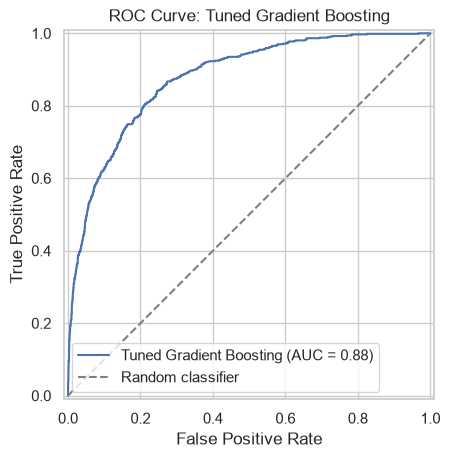

In [235]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(
    y_valid,
    tuned_validation_probabilities,
    name="Tuned Gradient Boosting"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("ROC Curve: Tuned Gradient Boosting")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [236]:
from sklearn.metrics import average_precision_score

validation_average_precision = average_precision_score(
    y_valid,
    tuned_validation_probabilities
)

print(
    "Validation Average Precision:",
    round(validation_average_precision, 3)
)

Validation Average Precision: 0.598


In [237]:
positive_class_baseline = y_valid.mean()

print(
    "Positive-class baseline:",
    round(positive_class_baseline, 3)
)

Positive-class baseline: 0.141


In [238]:
scoring_metrics_extended = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

In [239]:
print(gradient_boosting_cv_results.keys())

dict_keys(['fit_time', 'score_time', 'test_accuracy', 'test_balanced_accuracy', 'test_precision', 'test_recall', 'test_f1'])


In [240]:
scoring_metrics_extended = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

In [241]:
from sklearn.model_selection import cross_validate

gradient_boosting_cv_results_extended = cross_validate(
    estimator=gradient_boosting_pipeline,
    X=X_train,
    y=y_train,
    cv=stratified_kfold,
    scoring=scoring_metrics_extended,
    return_train_score=False,
    n_jobs=-1
)

In [242]:
mean_roc_auc = (
    gradient_boosting_cv_results_extended[
        "test_roc_auc"
    ].mean()
)

std_roc_auc = (
    gradient_boosting_cv_results_extended[
        "test_roc_auc"
    ].std()
)

print(f"Mean CV ROC-AUC: {mean_roc_auc:.3f}")
print(f"ROC-AUC standard deviation: {std_roc_auc:.3f}")

Mean CV ROC-AUC: 0.860
ROC-AUC standard deviation: 0.011


In [243]:
mean_average_precision = (
    gradient_boosting_cv_results_extended[
        "test_average_precision"
    ].mean()
)

std_average_precision = (
    gradient_boosting_cv_results_extended[
        "test_average_precision"
    ].std()
)

print(
    f"Mean CV Average Precision: "
    f"{mean_average_precision:.3f}"
)

print(
    f"Average Precision standard deviation: "
    f"{std_average_precision:.3f}"
)

Mean CV Average Precision: 0.580
Average Precision standard deviation: 0.025


In [244]:
extended_cv_summary = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC",
            "Average Precision"
        ],
        "Mean": [
            gradient_boosting_cv_results_extended[
                "test_accuracy"
            ].mean(),
            gradient_boosting_cv_results_extended[
                "test_balanced_accuracy"
            ].mean(),
            gradient_boosting_cv_results_extended[
                "test_precision"
            ].mean(),
            gradient_boosting_cv_results_extended[
                "test_recall"
            ].mean(),
            gradient_boosting_cv_results_extended[
                "test_f1"
            ].mean(),
            gradient_boosting_cv_results_extended[
                "test_roc_auc"
            ].mean(),
            gradient_boosting_cv_results_extended[
                "test_average_precision"
            ].mean()
        ],
        "Standard Deviation": [
            gradient_boosting_cv_results_extended[
                "test_accuracy"
            ].std(),
            gradient_boosting_cv_results_extended[
                "test_balanced_accuracy"
            ].std(),
            gradient_boosting_cv_results_extended[
                "test_precision"
            ].std(),
            gradient_boosting_cv_results_extended[
                "test_recall"
            ].std(),
            gradient_boosting_cv_results_extended[
                "test_f1"
            ].std(),
            gradient_boosting_cv_results_extended[
                "test_roc_auc"
            ].std(),
            gradient_boosting_cv_results_extended[
                "test_average_precision"
            ].std()
        ]
    }
).round(3)

extended_cv_summary

,Metric,Mean,Standard Deviation
0,Accuracy,0.888,0.003
1,Balanced Accuracy,0.650,0.010
2,Precision,0.731,0.025
3,Recall,0.319,0.021
4,F1 Score,0.444,0.023
5,ROC-AUC,0.860,0.011
6,Average Precision,0.580,0.025


In [245]:
from sklearn.metrics import roc_auc_score

validation_probabilities = (
    best_gradient_boosting_model
    .predict_proba(X_valid)[:, 1]
)

validation_roc_auc = roc_auc_score(
    y_valid,
    validation_probabilities
)

print(f"Validation ROC-AUC: {validation_roc_auc:.3f}")

Validation ROC-AUC: 0.877


In [246]:
print(test.shape)
print(train.shape)

(10086, 12)
(23524, 13)


In [247]:
'Test dataset prediction'

test_result_summary = pd.DataFrame({
    "Count": pd.Series(
        test_predictions
    ).value_counts().sort_index(),
    "Percentage": pd.Series(
        test_predictions
    ).value_counts(
        normalize=True
    ).sort_index().mul(100).round(2)
})

test_result_summary.index = [
    "No bank account (0)",
    "Has bank account (1)"
]

test_result_summary

,Count,Percentage
No bank account (0),9319,92.4
Has bank account (1),767,7.6


In [248]:
import sys

print("Python executable:", sys.executable)
print("Python version:", sys.version)

Python executable: /Users/nabilelfadel/neuefische_course/financial-inclusion-in-africa/.venv/bin/python
Python version: 3.13.14 (main, Jul 18 2026, 16:56:45) [Clang 22.1.3 ]


In [249]:
import subprocess
import sys

subprocess.check_call([
    sys.executable,
    "-m",
    "ensurepip",
    "--upgrade"
])

Looking in links: /var/folders/xd/z5xpb5h532dfrdy6xz3v34t40000gn/T/tmpg7dkamwn


0

In [250]:
import subprocess
import sys

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--upgrade",
    "pip"
])

0

In [251]:
import subprocess
import sys

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "xgboost"
])

0

In [252]:
import xgboost
from xgboost import XGBClassifier

print("XGBoost version:", xgboost.__version__)
print("XGBoost imported successfully.")

XGBoost version: 3.4.0
XGBoost imported successfully.


In [253]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import (
    cross_validate,
    cross_val_predict,
    RandomizedSearchCV,
    StratifiedKFold
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

In [254]:
print("Full labelled features:", X.shape)
print("Full target:", y.shape)

print("Development training features:", X_train.shape)
print("Held-out validation features:", X_valid.shape)

print("External test features:", X_test.shape)

Full labelled features: (23524, 11)
Full target: (23524,)
Development training features: (18819, 11)
Held-out validation features: (4705, 11)
External test features: (10086, 11)


In [255]:
print("Target values:", sorted(y.unique()))

Target values: [np.int64(0), np.int64(1)]


In [256]:
stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [257]:
f2_scorer = make_scorer(
    fbeta_score,
    beta=2,
    zero_division=0
)

In [258]:
scoring_metrics_xgboost = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "f2": f2_scorer,
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

In [259]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

imbalance_ratio = negative_count / positive_count

print("Negative observations:", negative_count)
print("Positive observations:", positive_count)
print("Negative-to-positive ratio:", round(imbalance_ratio, 2))

Negative observations: 16169
Positive observations: 2650
Negative-to-positive ratio: 6.1


In [260]:
xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                min_child_weight=1,
                gamma=0,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_alpha=0,
                reg_lambda=1,
                scale_pos_weight=1,
                random_state=42,
                n_jobs=1,
                verbosity=0
            )
        )
    ]
)

In [261]:
xgboost_cv_results = cross_validate(
    estimator=xgboost_pipeline,
    X=X_train,
    y=y_train,
    cv=stratified_kfold,
    scoring=scoring_metrics_xgboost,
    return_train_score=False,
    n_jobs=-1
)

In [262]:
xgboost_cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "F2 Score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Mean": [
        xgboost_cv_results["test_accuracy"].mean(),
        xgboost_cv_results[
            "test_balanced_accuracy"
        ].mean(),
        xgboost_cv_results["test_precision"].mean(),
        xgboost_cv_results["test_recall"].mean(),
        xgboost_cv_results["test_f1"].mean(),
        xgboost_cv_results["test_f2"].mean(),
        xgboost_cv_results["test_roc_auc"].mean(),
        xgboost_cv_results[
            "test_average_precision"
        ].mean()
    ],
    "Standard Deviation": [
        xgboost_cv_results["test_accuracy"].std(),
        xgboost_cv_results[
            "test_balanced_accuracy"
        ].std(),
        xgboost_cv_results["test_precision"].std(),
        xgboost_cv_results["test_recall"].std(),
        xgboost_cv_results["test_f1"].std(),
        xgboost_cv_results["test_f2"].std(),
        xgboost_cv_results["test_roc_auc"].std(),
        xgboost_cv_results[
            "test_average_precision"
        ].std()
    ]
}).round(3)

xgboost_cv_summary

,Metric,Mean,Standard Deviation
0,Accuracy,0.888,0.003
1,Balanced Accuracy,0.660,0.010
2,Precision,0.718,0.016
3,Recall,0.341,0.019
4,F1 Score,0.462,0.021
5,F2 Score,0.381,0.020
6,ROC-AUC,0.863,0.010
7,Average Precision,0.584,0.023


In [263]:
xgboost_comparison_row = pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [
        xgboost_cv_results["test_accuracy"].mean()
    ],
    "Balanced Accuracy": [
        xgboost_cv_results[
            "test_balanced_accuracy"
        ].mean()
    ],
    "Precision": [
        xgboost_cv_results["test_precision"].mean()
    ],
    "Recall": [
        xgboost_cv_results["test_recall"].mean()
    ],
    "F1 Score": [
        xgboost_cv_results["test_f1"].mean()
    ],
    "ROC-AUC": [
        xgboost_cv_results["test_roc_auc"].mean()
    ],
    "Average Precision": [
        xgboost_cv_results[
            "test_average_precision"
        ].mean()
    ]
})

xgboost_comparison_row["Error Rate"] = (
    1 - xgboost_comparison_row["Accuracy"]
)

xgboost_comparison_row.round(3)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision,Error Rate
0,XGBoost,0.888,0.66,0.718,0.341,0.462,0.863,0.584,0.112


In [264]:
extended_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Accuracy": [
        0.884,
        0.861,
        0.888,
        xgboost_cv_results["test_accuracy"].mean()
    ],
    "Balanced Accuracy": [
        0.655,
        0.658,
        0.650,
        xgboost_cv_results[
            "test_balanced_accuracy"
        ].mean()
    ],
    "Precision": [
        0.677,
        0.510,
        0.731,
        xgboost_cv_results["test_precision"].mean()
    ],
    "Recall": [
        0.336,
        0.375,
        0.319,
        xgboost_cv_results["test_recall"].mean()
    ],
    "F1 Score": [
        0.449,
        0.432,
        0.444,
        xgboost_cv_results["test_f1"].mean()
    ],
    "Error Rate": [
        0.116,
        0.139,
        0.112,
        1 - xgboost_cv_results["test_accuracy"].mean()
    ]
}).round(3)

extended_model_comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Error Rate
2,Gradient Boosting,0.888,0.650,0.731,0.319,0.444,0.112
3,XGBoost,0.888,0.660,0.718,0.341,0.462,0.112
0,Logistic Regression,0.884,0.655,0.677,0.336,0.449,0.116
1,Random Forest,0.861,0.658,0.510,0.375,0.432,0.139


In [265]:
xgboost_parameter_space = {
    "model__n_estimators": [
        200,
        300,
        500,
        700
    ],
    "model__learning_rate": [
        0.02,
        0.05,
        0.08,
        0.10
    ],
    "model__max_depth": [
        2,
        3,
        4,
        5
    ],
    "model__min_child_weight": [
        1,
        3,
        5,
        10
    ],
    "model__gamma": [
        0,
        0.10,
        0.25,
        0.50
    ],
    "model__subsample": [
        0.70,
        0.85,
        1.00
    ],
    "model__colsample_bytree": [
        0.70,
        0.85,
        1.00
    ],
    "model__reg_alpha": [
        0,
        0.01,
        0.10,
        1.00
    ],
    "model__reg_lambda": [
        1,
        2,
        5,
        10
    ],
    "model__scale_pos_weight": [
        1.0,
        2.0,
        3.0,
        4.0,
        5.0,
        round(imbalance_ratio, 2)
    ]
}

In [266]:
xgboost_search = RandomizedSearchCV(
    estimator=xgboost_pipeline,
    param_distributions=xgboost_parameter_space,
    n_iter=40,
    scoring=scoring_metrics_xgboost,
    refit="f2",
    cv=stratified_kfold,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

In [267]:
refit="accuracy"

In [268]:
xgboost_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END model__colsample_bytree=1.0, model__gamma=0.1, model__learning_rate=0.02, model__max_depth=3, model__min_child_weight=5, model__n_estimators=500, model__reg_alpha=0.01, model__reg_lambda=5, model__scale_pos_weight=3.0, model__subsample=0.85; total time=   0.4s
[CV] END model__colsample_bytree=1.0, model__gamma=0.1, model__learning_rate=0.02, model__max_depth=3, model__min_child_weight=5, model__n_estimators=500, model__reg_alpha=0.01, model__reg_lambda=5, model__scale_pos_weight=3.0, model__subsample=0.85; total time=   0.5s
[CV] END model__colsample_bytree=0.7, model__gamma=0.1, model__learning_rate=0.08, model__max_depth=4, model__min_child_weight=3, model__n_estimators=700, model__reg_alpha=0.01, model__reg_lambda=10, model__scale_pos_weight=3.0, model__subsample=1.0; total time=   0.6s
[CV] END model__colsample_bytree=0.7, model__gamma=0.1, model__learning_rate=0.08, model__max_depth=4, model__min_child_weight=3

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.85, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.02, 0.05, ...], 'model__max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'average_precision': 'average_precision', 'balanced_accuracy': 'balanced_accuracy', 'f1': 'f1', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`Strat

In [269]:
print("Best XGBoost parameters:")

for parameter, value in xgboost_search.best_params_.items():
    print(f"{parameter}: {value}")

Best XGBoost parameters:
model__subsample: 0.85
model__scale_pos_weight: 6.1
model__reg_lambda: 1
model__reg_alpha: 0.01
model__n_estimators: 200
model__min_child_weight: 5
model__max_depth: 3
model__learning_rate: 0.08
model__gamma: 0.25
model__colsample_bytree: 0.85


In [270]:
best_xgboost_model = (
    xgboost_search.best_estimator_
)

In [271]:
best_index = xgboost_search.best_index_

best_xgboost_cv_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "F2 Score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Mean CV Score": [
        xgboost_search.cv_results_[
            "mean_test_accuracy"
        ][best_index],
        xgboost_search.cv_results_[
            "mean_test_balanced_accuracy"
        ][best_index],
        xgboost_search.cv_results_[
            "mean_test_precision"
        ][best_index],
        xgboost_search.cv_results_[
            "mean_test_recall"
        ][best_index],
        xgboost_search.cv_results_[
            "mean_test_f1"
        ][best_index],
        xgboost_search.cv_results_[
            "mean_test_f2"
        ][best_index],
        xgboost_search.cv_results_[
            "mean_test_roc_auc"
        ][best_index],
        xgboost_search.cv_results_[
            "mean_test_average_precision"
        ][best_index]
    ]
}).round(3)

best_xgboost_cv_metrics

,Metric,Mean CV Score
0,Accuracy,0.786
1,Balanced Accuracy,0.778
2,Precision,0.374
3,Recall,0.767
4,F1 Score,0.503
5,F2 Score,0.634
6,ROC-AUC,0.863
7,Average Precision,0.583


In [272]:
mean_train_f2 = xgboost_search.cv_results_[
    "mean_train_f2"
][best_index]

mean_test_f2 = xgboost_search.cv_results_[
    "mean_test_f2"
][best_index]

print("Mean training F2:", round(mean_train_f2, 3))
print("Mean validation F2:", round(mean_test_f2, 3))
print(
    "Train-CV F2 gap:",
    round(mean_train_f2 - mean_test_f2, 3)
)

Mean training F2: 0.656
Mean validation F2: 0.634
Train-CV F2 gap: 0.022


In [273]:
xgboost_oof_probabilities = cross_val_predict(
    estimator=best_xgboost_model,
    X=X_train,
    y=y_train,
    cv=stratified_kfold,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [274]:
threshold_rows = []

for threshold in np.arange(0.10, 0.71, 0.01):
    predictions = (
        xgboost_oof_probabilities >= threshold
    ).astype(int)

    threshold_rows.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_train,
            predictions
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_train,
            predictions
        ),
        "Precision": precision_score(
            y_train,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_train,
            predictions,
            zero_division=0
        ),
        "F2 Score": fbeta_score(
            y_train,
            predictions,
            beta=2,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(
    threshold_rows
)

In [275]:
best_threshold_row = threshold_results.loc[
    threshold_results["F2 Score"].idxmax()
]

best_recall_threshold = float(
    best_threshold_row["Threshold"]
)

print(
    "Selected recall-focused threshold:",
    round(best_recall_threshold, 2)
)

display(
    best_threshold_row.to_frame(
        name="Score"
    ).round(3)
)

Selected recall-focused threshold: 0.46


,Score
Threshold,0.460
Accuracy,0.764
Balanced Accuracy,0.779
Precision,0.351
Recall,0.799
F1 Score,0.488
F2 Score,0.637


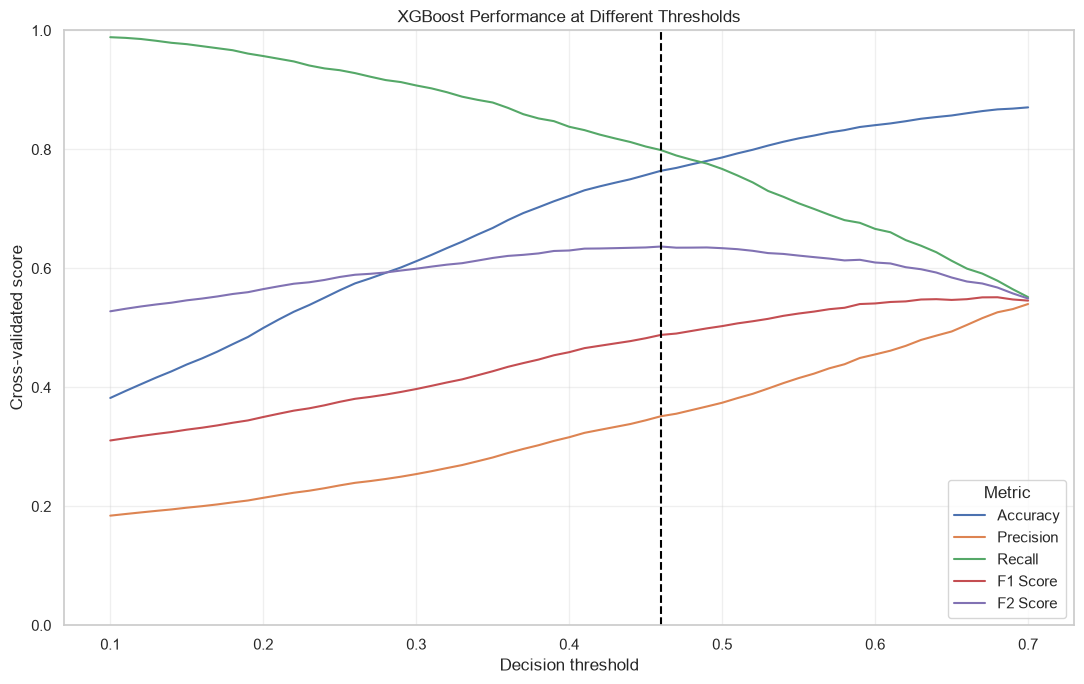

In [276]:
threshold_plot_data = threshold_results.melt(
    id_vars="Threshold",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "F2 Score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 7))

sns.lineplot(
    data=threshold_plot_data,
    x="Threshold",
    y="Score",
    hue="Metric"
)

plt.axvline(
    best_recall_threshold,
    color="black",
    linestyle="--",
    label="Selected F2 threshold"
)

plt.title(
    "XGBoost Performance at Different Thresholds"
)
plt.xlabel("Decision threshold")
plt.ylabel("Cross-validated score")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [277]:
xgboost_validation_probabilities = (
    best_xgboost_model.predict_proba(
        X_valid
    )[:, 1]
)

In [278]:
xgboost_predictions_default = (
    xgboost_validation_probabilities >= 0.50
).astype(int)

In [279]:
xgboost_predictions_recall = (
    xgboost_validation_probabilities
    >= best_recall_threshold
).astype(int)

In [280]:
def create_evaluation_row(
    model_name,
    y_true,
    predictions,
    probabilities
):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Error Rate": 1 - accuracy_score(
            y_true,
            predictions
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F2 Score": fbeta_score(
            y_true,
            predictions,
            beta=2,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        ),
        "Average Precision": average_precision_score(
            y_true,
            probabilities
        )
    }

In [281]:
xgboost_validation_comparison = pd.DataFrame([
    create_evaluation_row(
        model_name="XGBoost, threshold 0.50",
        y_true=y_valid,
        predictions=xgboost_predictions_default,
        probabilities=xgboost_validation_probabilities
    ),
    create_evaluation_row(
        model_name=(
            "XGBoost, recall-focused threshold"
        ),
        y_true=y_valid,
        predictions=xgboost_predictions_recall,
        probabilities=xgboost_validation_probabilities
    )
]).round(3)

xgboost_validation_comparison

,Model,Accuracy,Error Rate,Balanced Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
0,"XGBoost, threshold 0.50",0.791,0.209,0.794,0.384,0.799,0.518,0.657,0.876,0.596
1,"XGBoost, recall-focused threshold",0.767,0.233,0.795,0.359,0.834,0.502,0.660,0.876,0.596


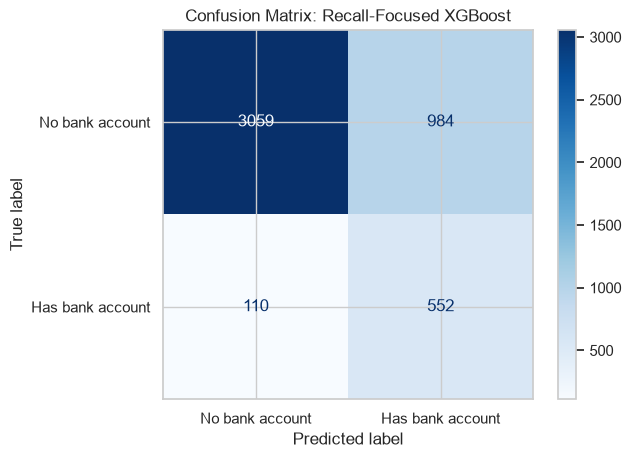

In [282]:
xgboost_cm = confusion_matrix(
    y_valid,
    xgboost_predictions_recall,
    labels=[0, 1]
)

xgboost_cm_display = ConfusionMatrixDisplay(
    confusion_matrix=xgboost_cm,
    display_labels=[
        "No bank account",
        "Has bank account"
    ]
)

xgboost_cm_display.plot(
    cmap="Blues"
)

plt.title(
    "Confusion Matrix: Recall-Focused XGBoost"
)

plt.show()

In [283]:
print(
    classification_report(
        y_valid,
        xgboost_predictions_recall,
        target_names=[
            "No bank account",
            "Has bank account"
        ],
        zero_division=0
    )
)

                  precision    recall  f1-score   support

 No bank account       0.97      0.76      0.85      4043
Has bank account       0.36      0.83      0.50       662

        accuracy                           0.77      4705
       macro avg       0.66      0.80      0.68      4705
    weighted avg       0.88      0.77      0.80      4705



In [284]:
xgboost_permutation_results = permutation_importance(
    estimator=best_xgboost_model,
    X=X_valid,
    y=y_valid,
    scoring=f2_scorer,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

In [285]:
xgboost_importance_table = pd.DataFrame({
    "Feature": X_valid.columns,
    "Importance Mean": (
        xgboost_permutation_results.importances_mean
    ),
    "Importance Standard Deviation": (
        xgboost_permutation_results.importances_std
    )
}).sort_values(
    by="Importance Mean",
    ascending=False
).reset_index(drop=True)

xgboost_importance_table.round(4)

,Feature,Importance Mean,Importance Standard Deviation
0,education_level,0.1156,0.0124
1,cellphone_access,0.0769,0.0094
2,country,0.0568,0.0095
3,job_type,0.0558,0.0065
4,age_of_respondent,0.0479,0.0080
5,location_type,0.0206,0.0040
6,year,0.0136,0.0031
7,gender_of_respondent,0.0134,0.0050
8,relationship_with_head,0.0030,0.0047
9,household_size,0.0017,0.0025


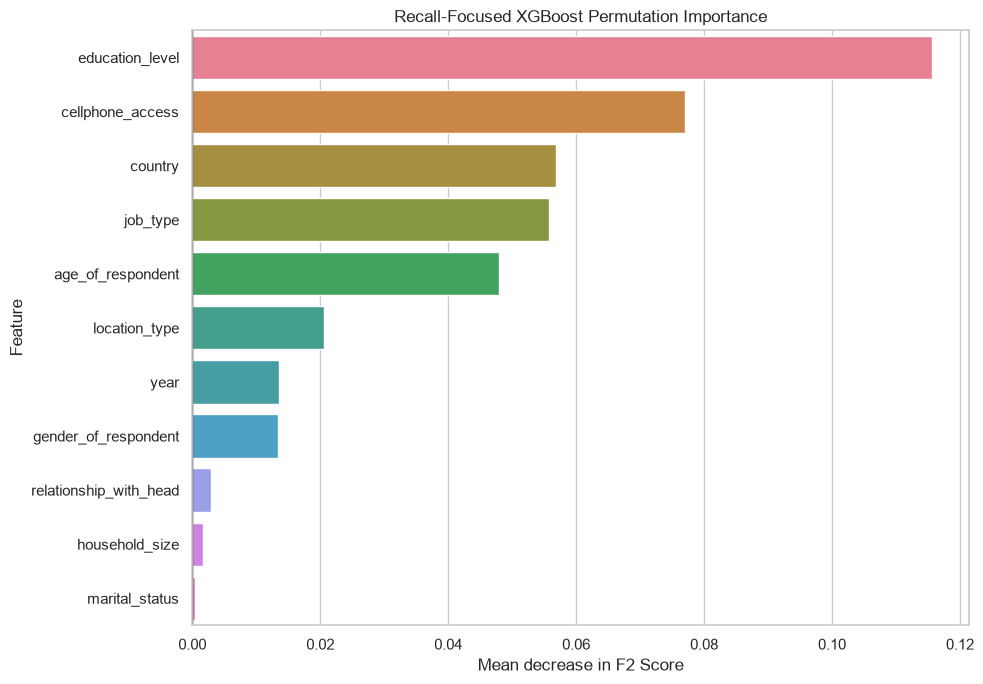

In [286]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=xgboost_importance_table,
    x="Importance Mean",
    y="Feature",
    hue="Feature",
    legend=False
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.title(
    "Recall-Focused XGBoost Permutation Importance"
)
plt.xlabel("Mean decrease in F2 Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [287]:
final_xgboost_model = clone(
    best_xgboost_model
)

In [288]:
final_xgboost_model.fit(
    X,
    y
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['country','year','location_type',...,'marital_status','education_level', 'job_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [289]:
print(
    "Final XGBoost pipeline trained on",
    len(X),
    "labelled respondents."
)

Final XGBoost pipeline trained on 23524 labelled respondents.


In [290]:
xgboost_test_probabilities = (
    final_xgboost_model.predict_proba(
        X_test
    )[:, 1]
)

In [291]:
xgboost_test_predictions_accuracy = (
    xgboost_test_probabilities >= 0.50
).astype(int)

In [292]:
xgboost_test_predictions_recall = (
    xgboost_test_probabilities
    >= best_recall_threshold
).astype(int)

In [293]:
test_prediction_comparison = pd.DataFrame({
    "Accuracy-focused": pd.Series(
        xgboost_test_predictions_accuracy
    ).value_counts(normalize=True),
    "Recall-focused": pd.Series(
        xgboost_test_predictions_recall
    ).value_counts(normalize=True)
}).mul(100).round(2)

test_prediction_comparison.index = [
    "No bank account",
    "Has bank account"
]

test_prediction_comparison

,Accuracy-focused,Recall-focused
No bank account,70.85,67.44
Has bank account,29.15,32.56


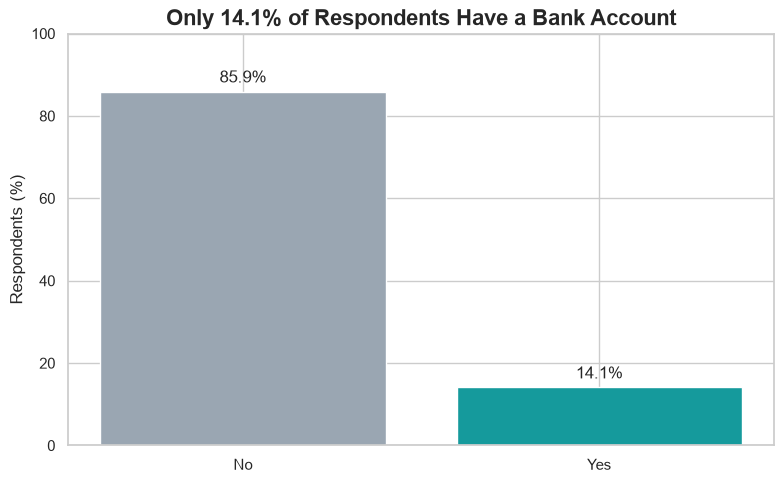

In [294]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

target_distribution = (
    train["bank_account"]
    .value_counts(normalize=True)
    .reindex(["No", "Yes"])
    .mul(100)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    target_distribution.index,
    target_distribution.values,
    color=["#9AA6B2", "#159A9C"]
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in target_distribution.values
    ],
    padding=4,
    fontsize=12
)

ax.set_title(
    "Only 14.1% of Respondents Have a Bank Account",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("")
ax.set_ylabel("Respondents (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

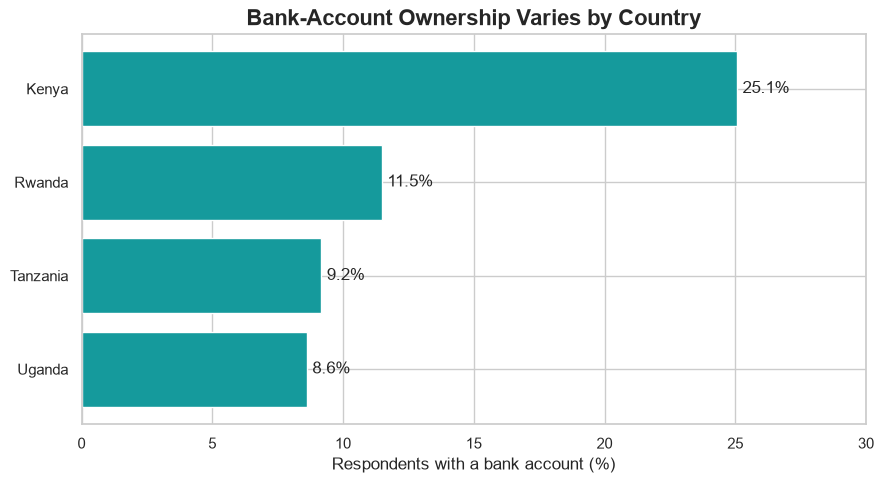

In [295]:
eda_data = train.copy()

eda_data["has_account"] = (
    eda_data["bank_account"]
    .eq("Yes")
    .astype(int)
)

country_rates = (
    eda_data
    .groupby("country", observed=True)
    ["has_account"]
    .agg(
        account_rate="mean",
        respondents="size"
    )
    .reset_index()
)

country_rates["account_rate"] = (
    country_rates["account_rate"] * 100
)

country_rates = country_rates.sort_values(
    "account_rate",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    country_rates["country"],
    country_rates["account_rate"],
    color="#159A9C"
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in country_rates["account_rate"]
    ],
    padding=4
)

ax.set_title(
    "Bank-Account Ownership Varies by Country",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Respondents with a bank account (%)")
ax.set_ylabel("")
ax.set_xlim(0, 30)

plt.tight_layout()
plt.show()

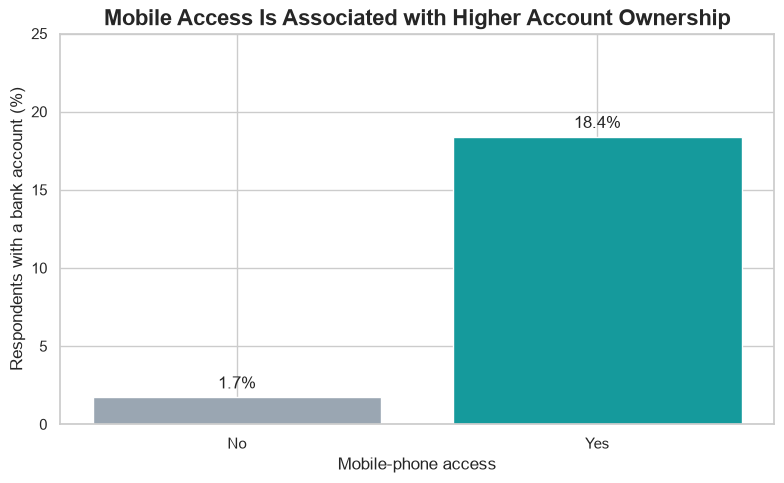

In [296]:
mobile_rates = (
    eda_data
    .groupby("cellphone_access", observed=True)
    ["has_account"]
    .agg(
        account_rate="mean",
        respondents="size"
    )
    .reset_index()
)

mobile_rates["account_rate"] *= 100

mobile_order = ["No", "Yes"]

mobile_rates["cellphone_access"] = pd.Categorical(
    mobile_rates["cellphone_access"],
    categories=mobile_order,
    ordered=True
)

mobile_rates = mobile_rates.sort_values(
    "cellphone_access"
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    mobile_rates["cellphone_access"],
    mobile_rates["account_rate"],
    color=["#9AA6B2", "#159A9C"]
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in mobile_rates["account_rate"]
    ],
    padding=4,
    fontsize=12
)

ax.set_title(
    "Mobile Access Is Associated with Higher Account Ownership",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Mobile-phone access")
ax.set_ylabel("Respondents with a bank account (%)")
ax.set_ylim(0, 25)

plt.tight_layout()
plt.show()

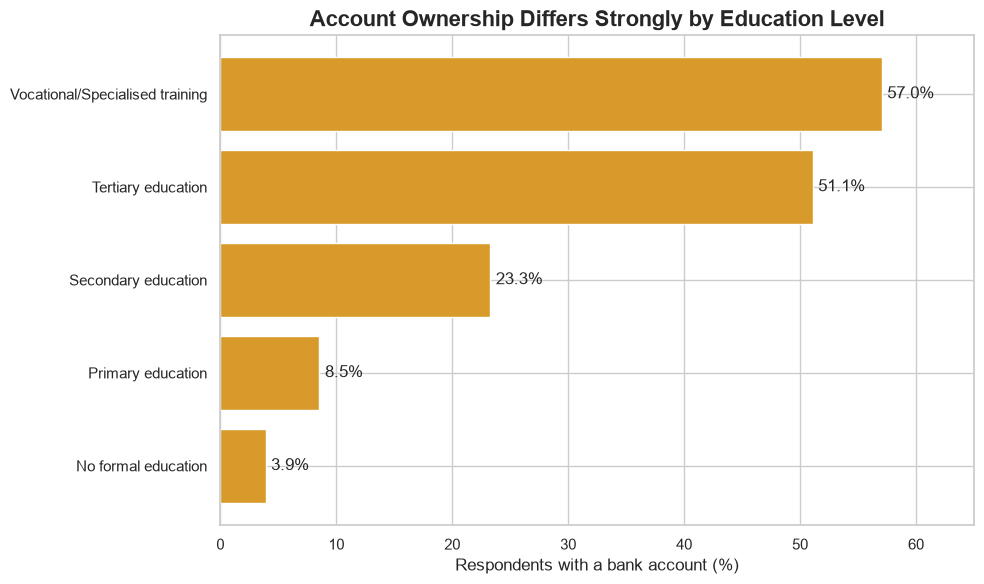

In [297]:
education_rates = (
    eda_data
    .groupby("education_level", observed=True)
    ["has_account"]
    .agg(
        account_rate="mean",
        respondents="size"
    )
    .reset_index()
)

education_rates["account_rate"] *= 100

# Remove categories with very small samples from the main chart
education_rates = education_rates[
    education_rates["respondents"] >= 100
].copy()

education_rates = education_rates.sort_values(
    "account_rate",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    education_rates["education_level"],
    education_rates["account_rate"],
    color="#D89B2B"
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in education_rates["account_rate"]
    ],
    padding=4
)

ax.set_title(
    "Account Ownership Differs Strongly by Education Level",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Respondents with a bank account (%)")
ax.set_ylabel("")
ax.set_xlim(0, 65)

plt.tight_layout()
plt.show()

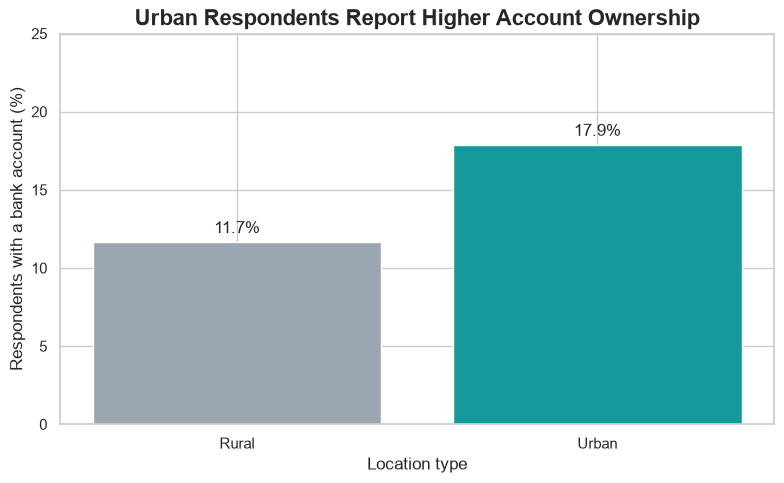

In [298]:
location_rates = (
    eda_data
    .groupby("location_type", observed=True)
    ["has_account"]
    .agg(
        account_rate="mean",
        respondents="size"
    )
    .reset_index()
)

location_rates["account_rate"] *= 100

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    location_rates["location_type"],
    location_rates["account_rate"],
    color=["#9AA6B2", "#159A9C"]
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in location_rates["account_rate"]
    ],
    padding=4
)

ax.set_title(
    "Urban Respondents Report Higher Account Ownership",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Location type")
ax.set_ylabel("Respondents with a bank account (%)")
ax.set_ylim(0, 25)

plt.tight_layout()
plt.show()

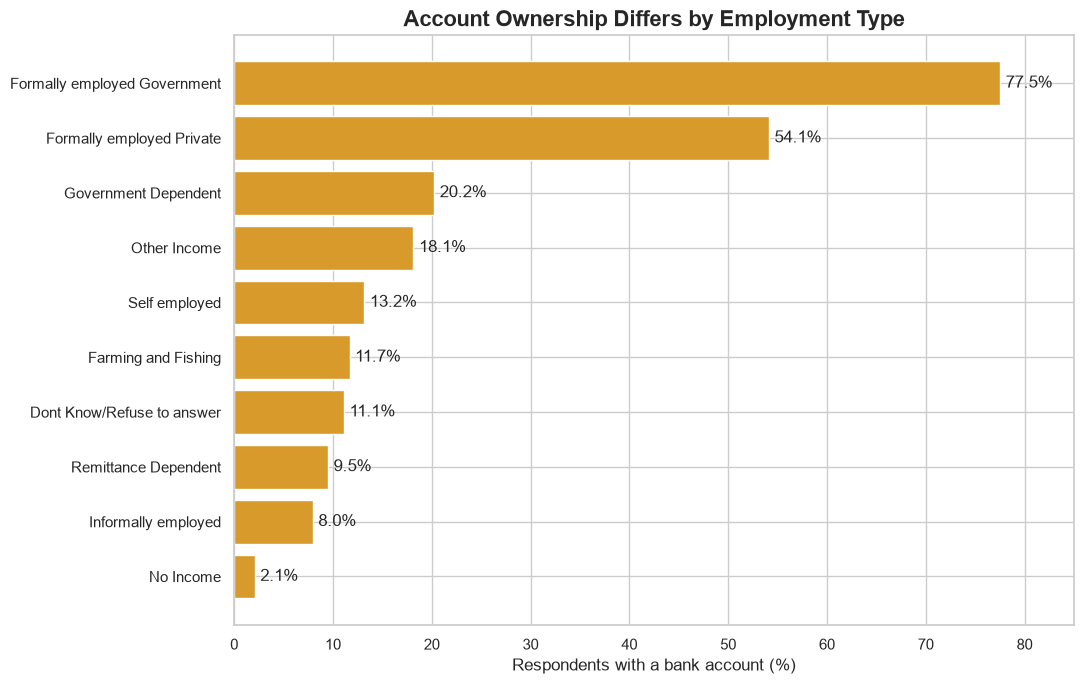

In [299]:
job_rates = (
    eda_data
    .groupby("job_type", observed=True)
    ["has_account"]
    .agg(
        account_rate="mean",
        respondents="size"
    )
    .reset_index()
)

job_rates["account_rate"] *= 100

job_rates = job_rates.sort_values(
    "account_rate",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    job_rates["job_type"],
    job_rates["account_rate"],
    color="#D89B2B"
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in job_rates["account_rate"]
    ],
    padding=4
)

ax.set_title(
    "Account Ownership Differs by Employment Type",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Respondents with a bank account (%)")
ax.set_ylabel("")
ax.set_xlim(0, 85)

plt.tight_layout()
plt.show()